# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [8]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [22]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



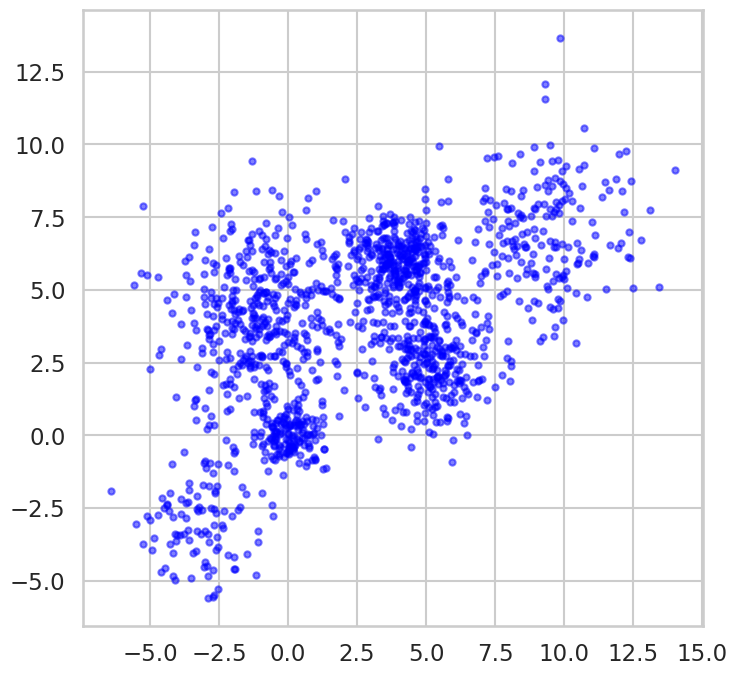

In [24]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

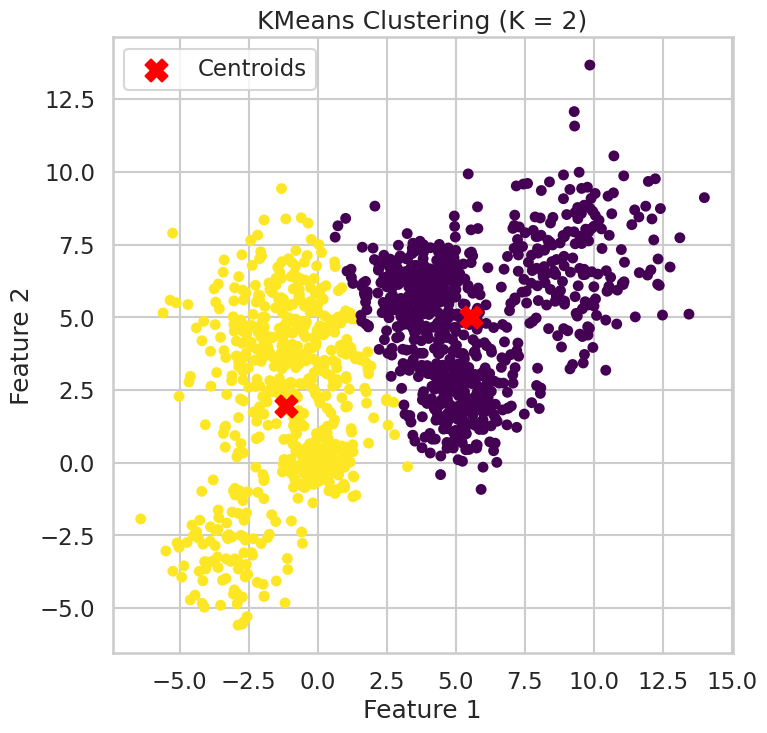

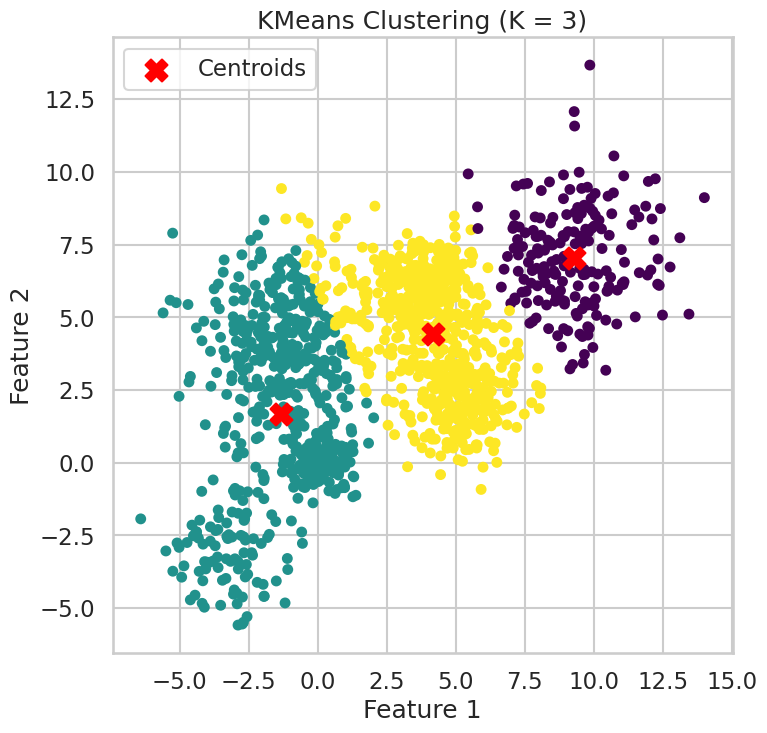

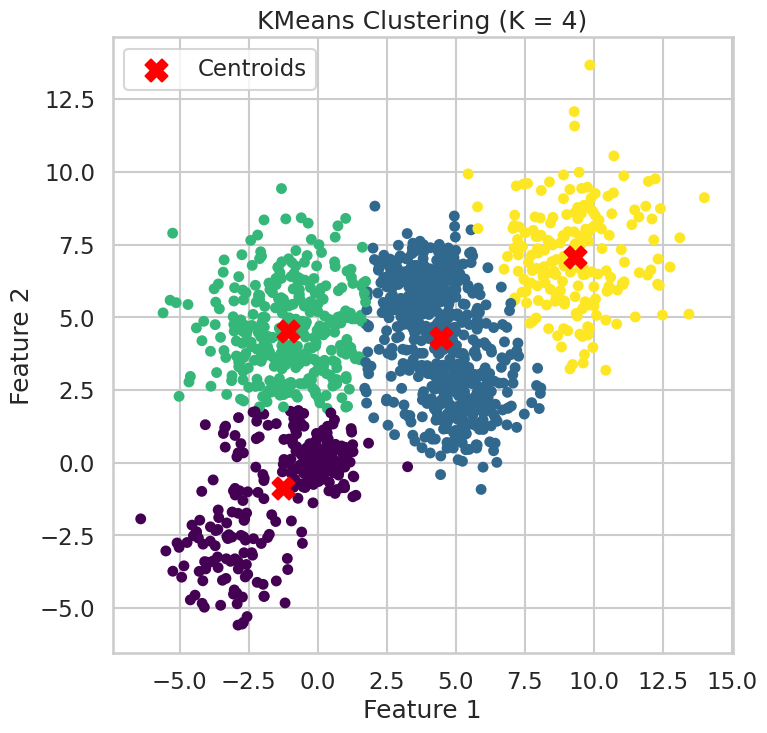

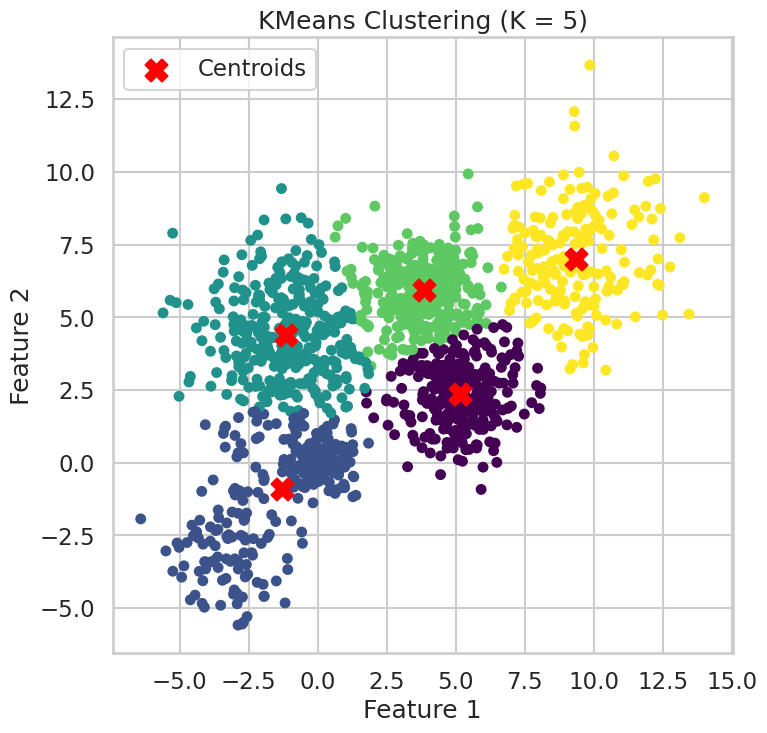

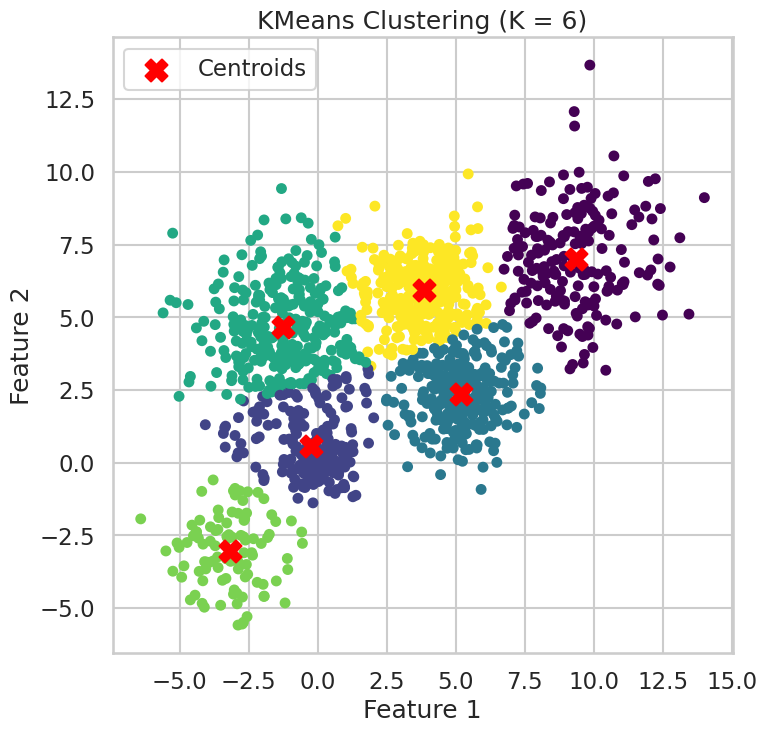

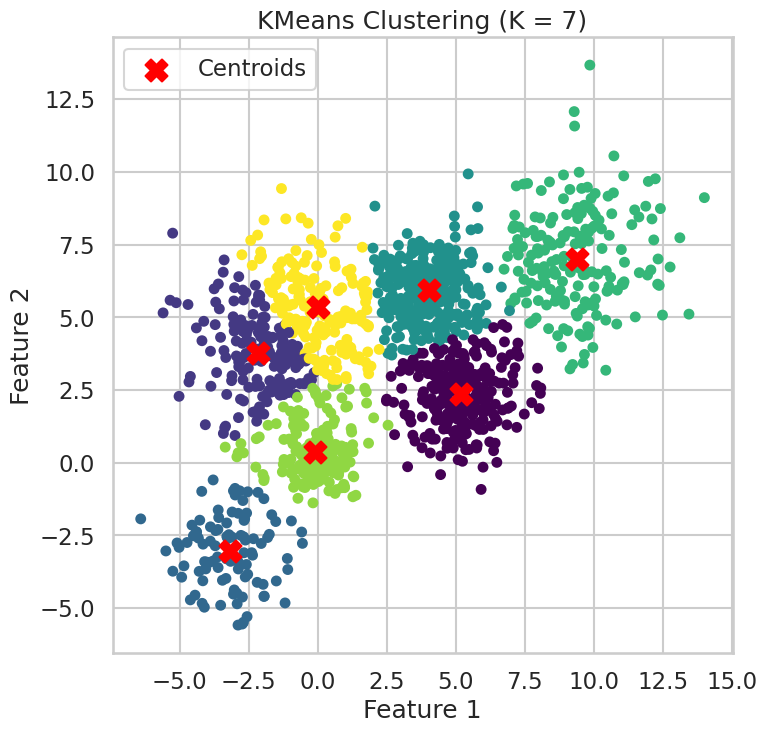

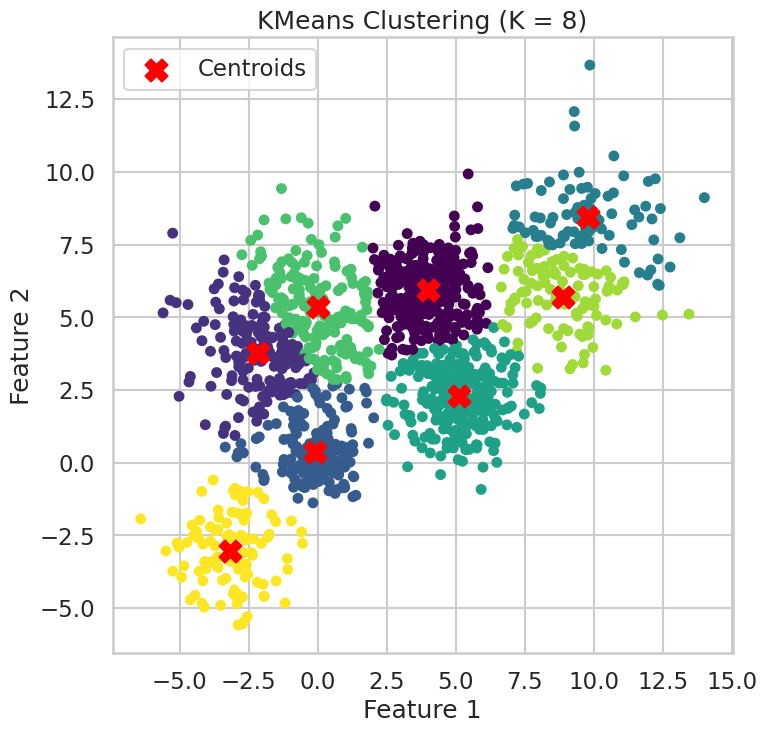

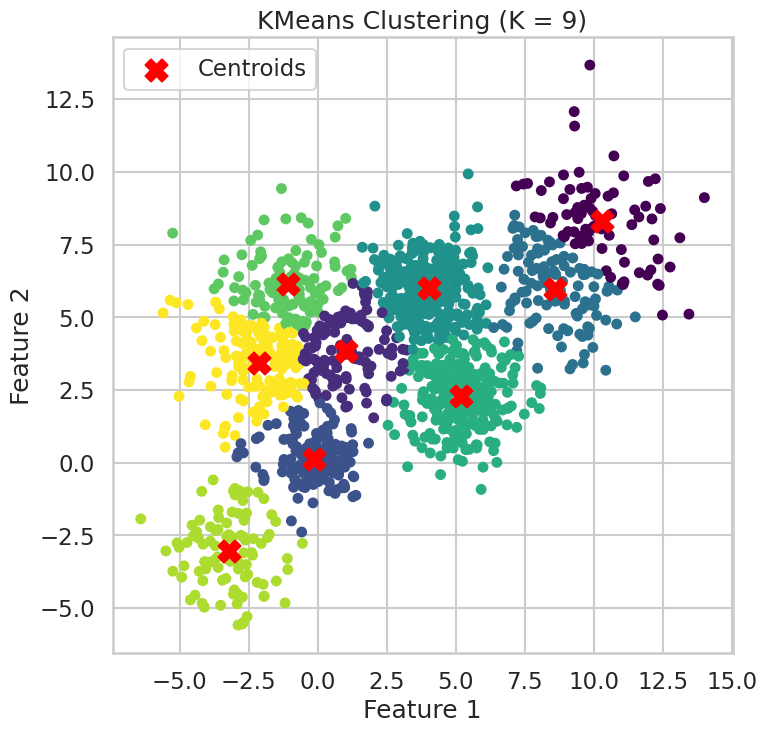

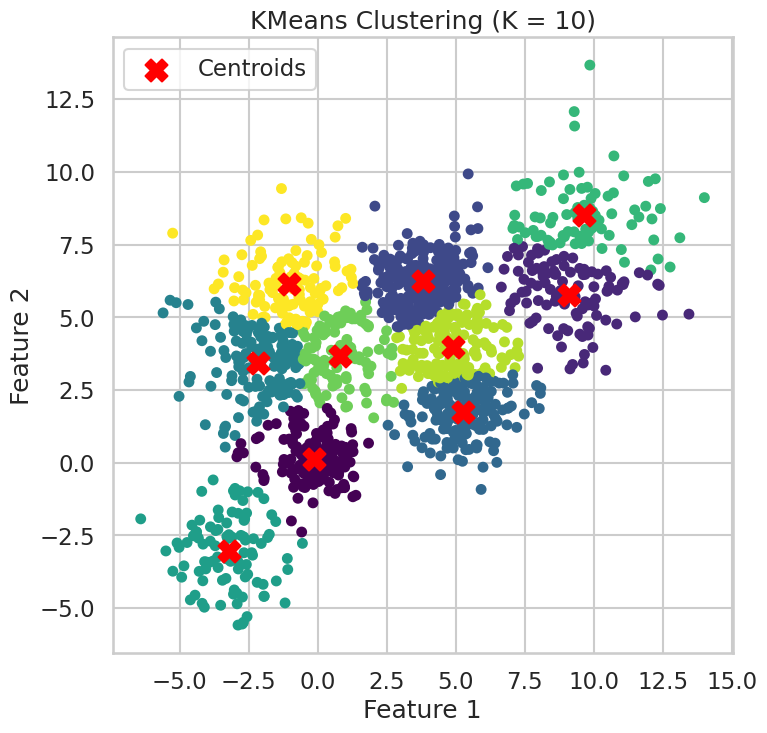

In [25]:
# ===============================
# KMeans with different values of K
# ===============================

# Range of K values we want to test
k_values = range(2, 11)

# Lists to store evaluation metrics
distortions = []        # distortion (inertia)
silhouette_scores = []  # silhouette score

for k in k_values:

    # Create KMeans model
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',   # smart centroid initialization
        n_init=10,          # run algorithm 10 times and choose best
        random_state=42
    )

    # Fit model and get cluster labels
    labels = kmeans.fit_predict(Multi_blob_Data)

    # Store distortion (inertia)
    distortions.append(kmeans.inertia_)

    # Compute silhouette score
    sil_score = silhouette_score(Multi_blob_Data, labels)
    silhouette_scores.append(sil_score)

    # -----------------------------
    # Plot the clustering result
    # -----------------------------

    plt.figure(figsize=(8,8))

    # Scatter plot colored by cluster assignment
    plt.scatter(
        Multi_blob_Data[:,0],
        Multi_blob_Data[:,1],
        c=labels,
        cmap='viridis',
        s=40
    )

    # Plot cluster centers
    plt.scatter(
        kmeans.cluster_centers_[:,0],
        kmeans.cluster_centers_[:,1],
        c='red',
        marker='X',
        s=250,
        label='Centroids'
    )

    plt.title(f'KMeans Clustering (K = {k})')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

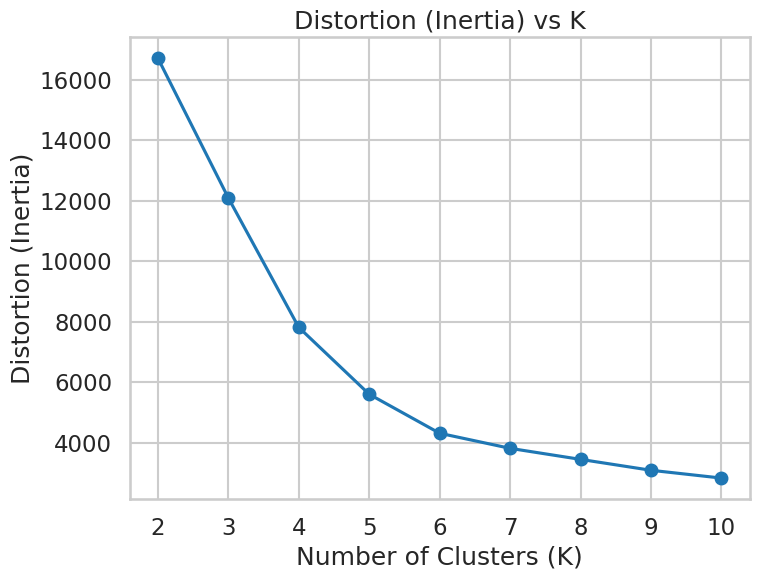

In [26]:
plt.figure(figsize=(8,6))

plt.plot(k_values, distortions, marker='o')

plt.title("Distortion (Inertia) vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Distortion (Inertia)")

plt.show()

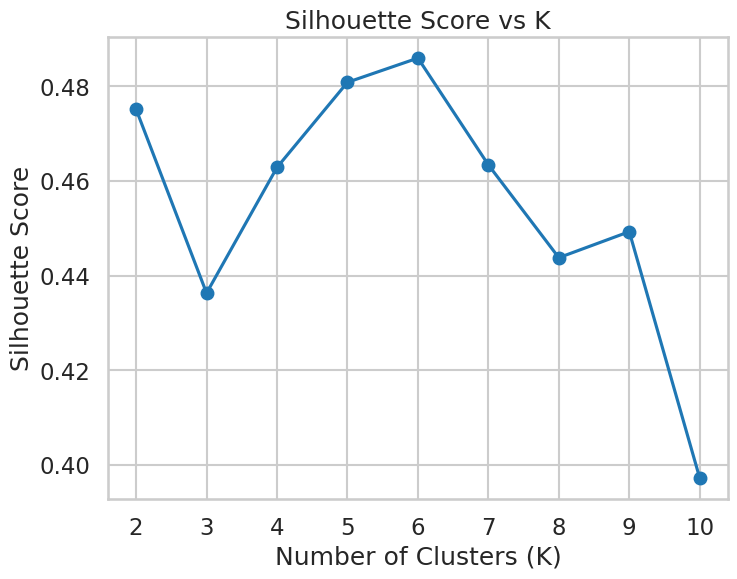

In [27]:
plt.figure(figsize=(8,6))

plt.plot(k_values, silhouette_scores, marker='o')

plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.show()

In [28]:
best_index = np.argmax(silhouette_scores)

best_k = list(k_values)[best_index]
best_k_silhouette = silhouette_scores[best_index]

print("Best K according to silhouette score:", best_k)
print("Best silhouette score:", best_k_silhouette)

Best K according to silhouette score: 6
Best silhouette score: 0.4859737366910219


In [29]:
best_kmeans_silhouette_score = best_k_silhouette

print("Stored best KMeans silhouette score:", best_kmeans_silhouette_score)

Stored best KMeans silhouette score: 0.4859737366910219


The initialization of centroids plays an important role in the KMeans clustering algorithm. Since KMeans optimizes cluster assignments by iteratively updating centroid positions, the initial placement of centroids can influence the final clustering result. If centroids are initialized randomly, the algorithm may converge to a suboptimal solution because it can get stuck in a local minimum.
To address this issue, the k-means++ initialization method is commonly used. This method selects the initial centroids in a way that spreads them across the data space by choosing new centroids with probability proportional to their distance from already selected centroids. This approach helps the algorithm start with well-separated centroids and generally improves clustering stability and convergence speed.
In this experiment, KMeans was applied with different values of
K
K, and the silhouette score was used to determine the optimal number of clusters. The best clustering result was obtained when K = 6, with a silhouette score of 0.486. This result aligns with the underlying structure of the generated dataset, which was created using six cluster centers. The use of k-means++ initialization helps ensure that the algorithm begins with good centroid positions, leading to more reliable cluster assignments.


### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

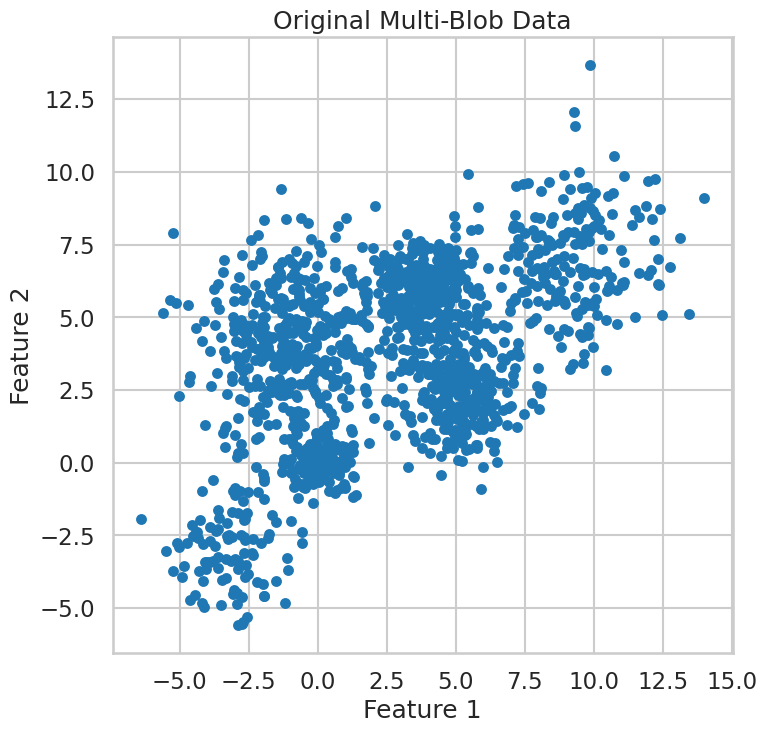

In [30]:
# AgglomerativeClustering is the hierarchical clustering model
from sklearn.cluster import AgglomerativeClustering

# linkage and dendrogram are used to draw the dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram
# Plot the original multi-blob data before applying hierarchical clustering
plt.figure(figsize=(8,8))
plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], s=40)
plt.title("Original Multi-Blob Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Silhouette score for first hierarchical trial: 0.4686938472105883


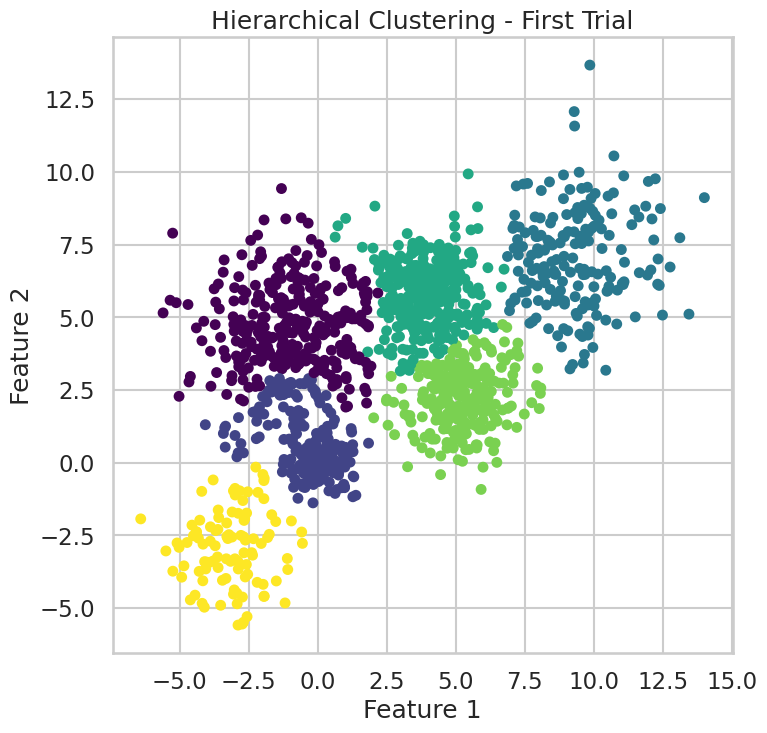

In [31]:
# A simple first trial of hierarchical clustering
# We use 6 clusters because KMeans previously suggested K=6
hier_model = AgglomerativeClustering(
    n_clusters=6,          # target number of clusters
    metric='euclidean',    # distance function between points
    linkage='ward'         # ward minimizes variance inside clusters
)

# Fit the model and get cluster labels
hier_labels = hier_model.fit_predict(Multi_blob_Data)

# Calculate silhouette score for this trial
hier_sil = silhouette_score(Multi_blob_Data, hier_labels)

print("Silhouette score for first hierarchical trial:", hier_sil)

# Display clustered result
plt.figure(figsize=(8,8))
plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=hier_labels, cmap='viridis', s=40)
plt.title("Hierarchical Clustering - First Trial")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [32]:
# Lists of parameters to test
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']

# Empty list to store all trial results
hier_results = []

# Try all valid metric-linkage combinations
for metric in metrics:
    for linkage_method in linkages:

        # ward linkage only works with euclidean distance
        if linkage_method == 'ward' and metric != 'euclidean':
            continue

        try:
            # Build the hierarchical clustering model
            model = AgglomerativeClustering(
                n_clusters=6,              # keep 6 clusters for comparison
                metric=metric,             # distance function
                linkage=linkage_method     # linkage strategy
            )

            # Predict cluster labels
            labels = model.fit_predict(Multi_blob_Data)

            # Calculate silhouette score
            sil = silhouette_score(Multi_blob_Data, labels)

            # Store the result for later comparison
            hier_results.append({
                'metric': metric,
                'linkage': linkage_method,
                'silhouette_score': sil
            })

            # Print trial result
            print(f"Metric: {metric}, Linkage: {linkage_method}, Silhouette Score: {sil:.4f}")

        except Exception as e:
            print(f"Metric: {metric}, Linkage: {linkage_method} --> Error: {e}")

Metric: euclidean, Linkage: ward, Silhouette Score: 0.4687
Metric: euclidean, Linkage: complete, Silhouette Score: 0.3819
Metric: euclidean, Linkage: average, Silhouette Score: 0.4148
Metric: euclidean, Linkage: single, Silhouette Score: 0.0871
Metric: manhattan, Linkage: complete, Silhouette Score: 0.3370
Metric: manhattan, Linkage: average, Silhouette Score: 0.3803
Metric: manhattan, Linkage: single, Silhouette Score: 0.0871
Metric: cosine, Linkage: complete, Silhouette Score: 0.1885
Metric: cosine, Linkage: average, Silhouette Score: 0.2036
Metric: cosine, Linkage: single, Silhouette Score: 0.0716


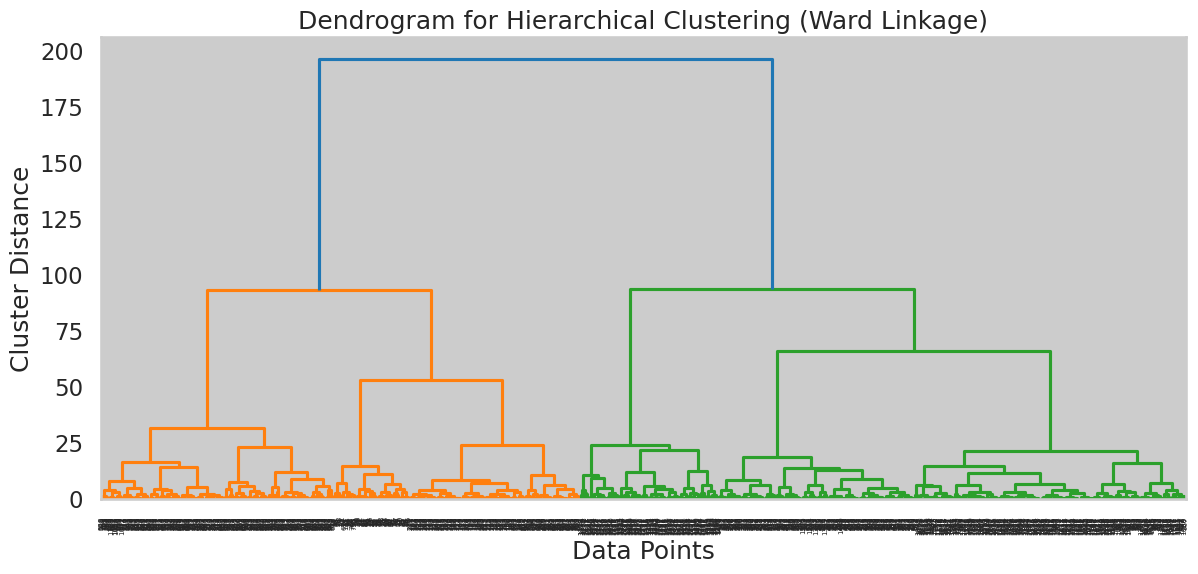

In [33]:
# Build linkage matrix for dendrogram plotting
# method='ward' works only with Euclidean distance
linked = linkage(Multi_blob_Data, method='ward')

# Plot the dendrogram
plt.figure(figsize=(14,6))
dendrogram(linked)

plt.title("Dendrogram for Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Cluster Distance")
plt.show()

In [34]:
# Convert results to DataFrame for better display
hier_results_df = pd.DataFrame(hier_results)

# Sort by silhouette score from best to worst
hier_results_df = hier_results_df.sort_values(by='silhouette_score', ascending=False)

# Display the table
hier_results_df

,metric,linkage,silhouette_score
0,euclidean,ward,0.468694
2,euclidean,average,0.414788
1,euclidean,complete,0.381931
5,manhattan,average,0.380298
4,manhattan,complete,0.337013
8,cosine,average,0.203558
7,cosine,complete,0.188503
3,euclidean,single,0.087056
6,manhattan,single,0.087056
9,cosine,single,0.071622


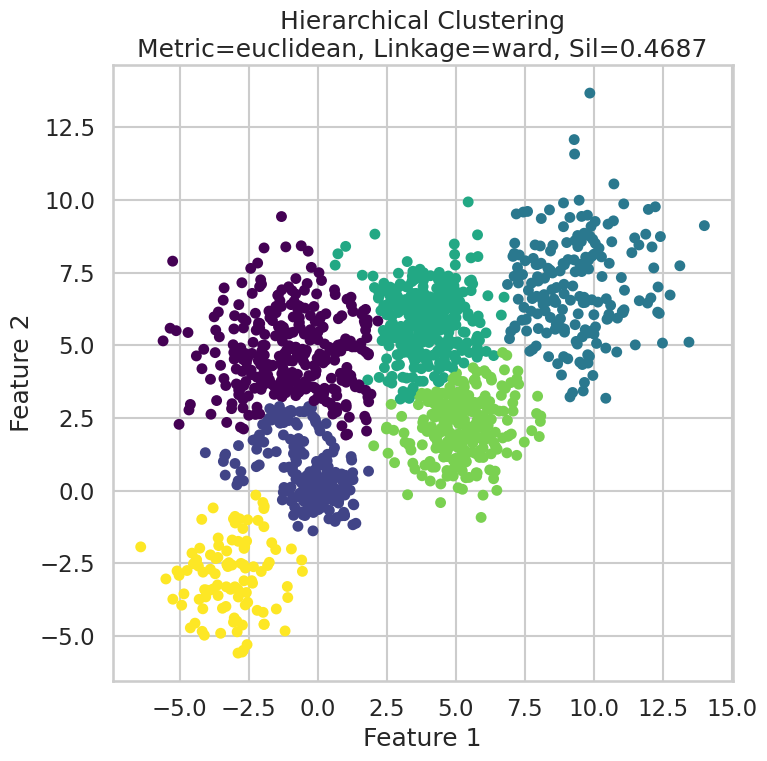

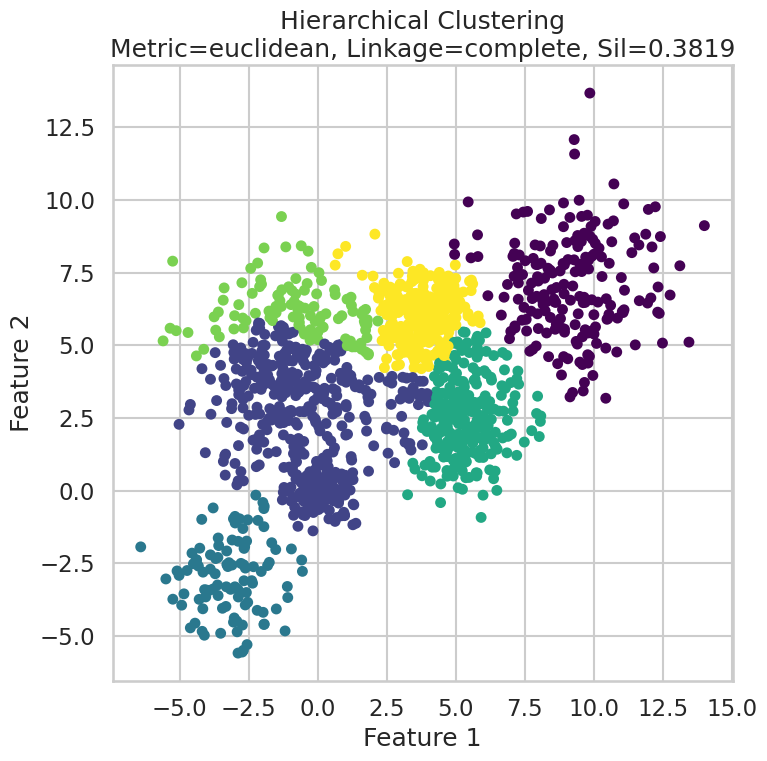

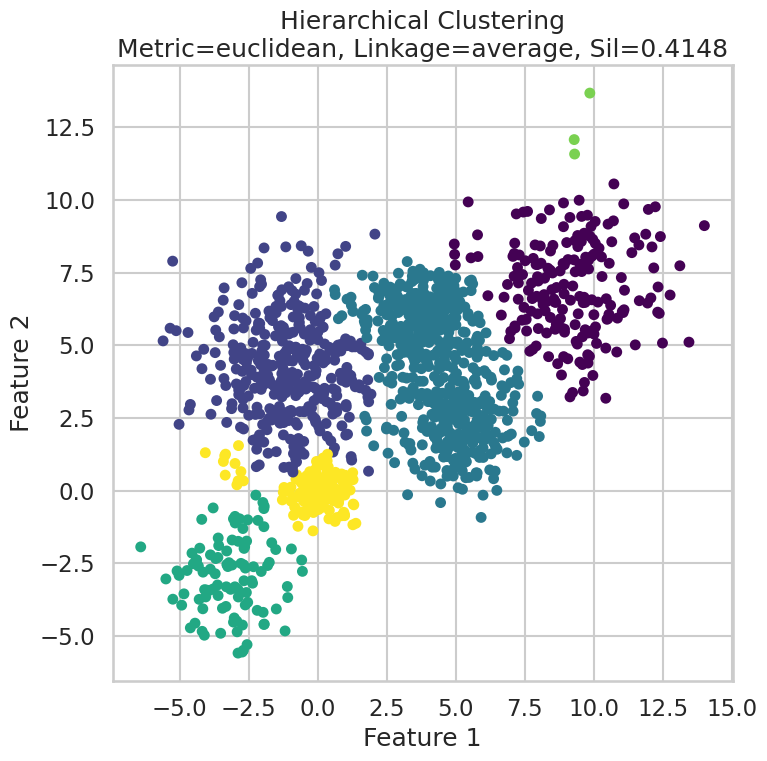

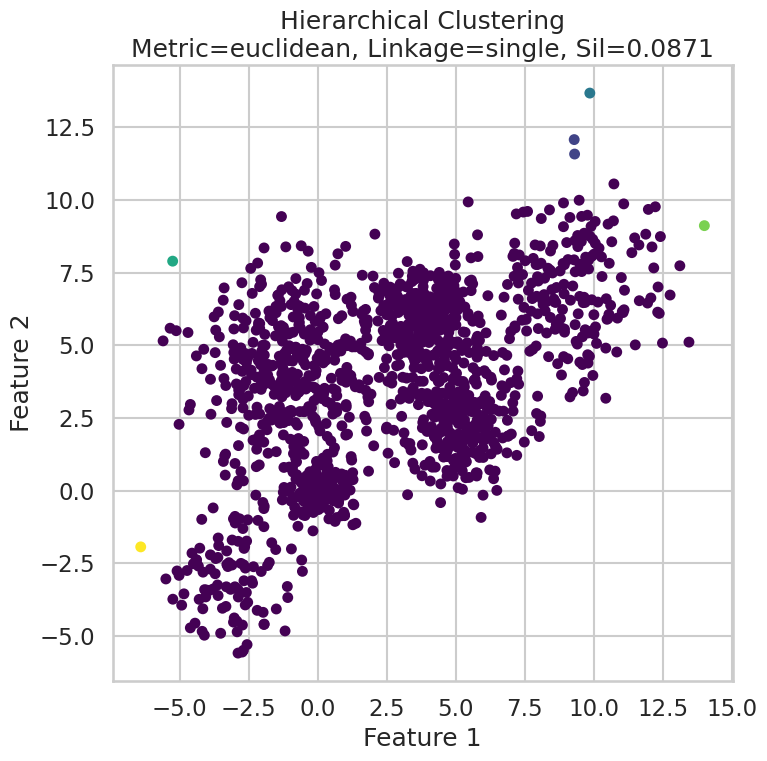

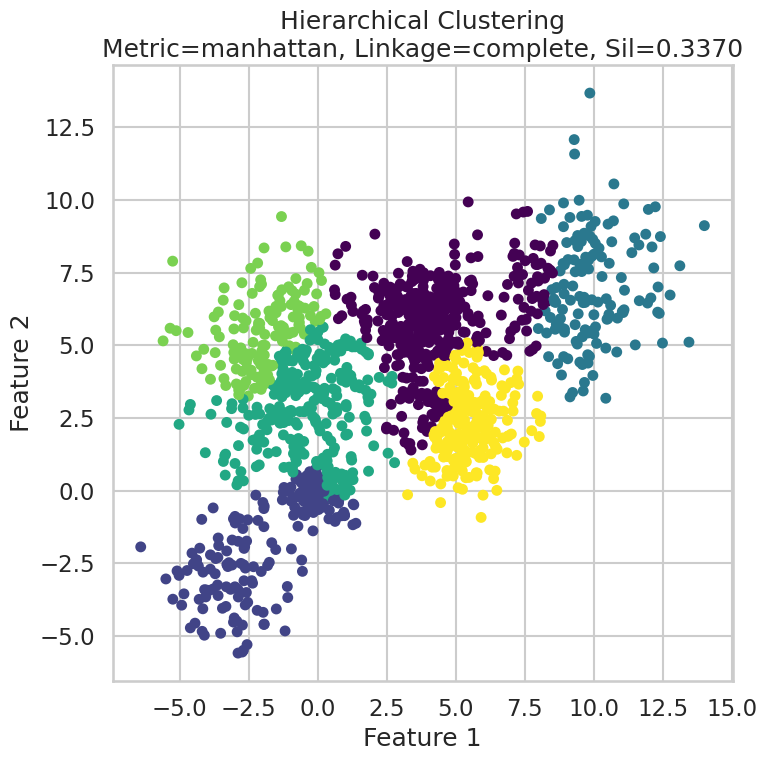

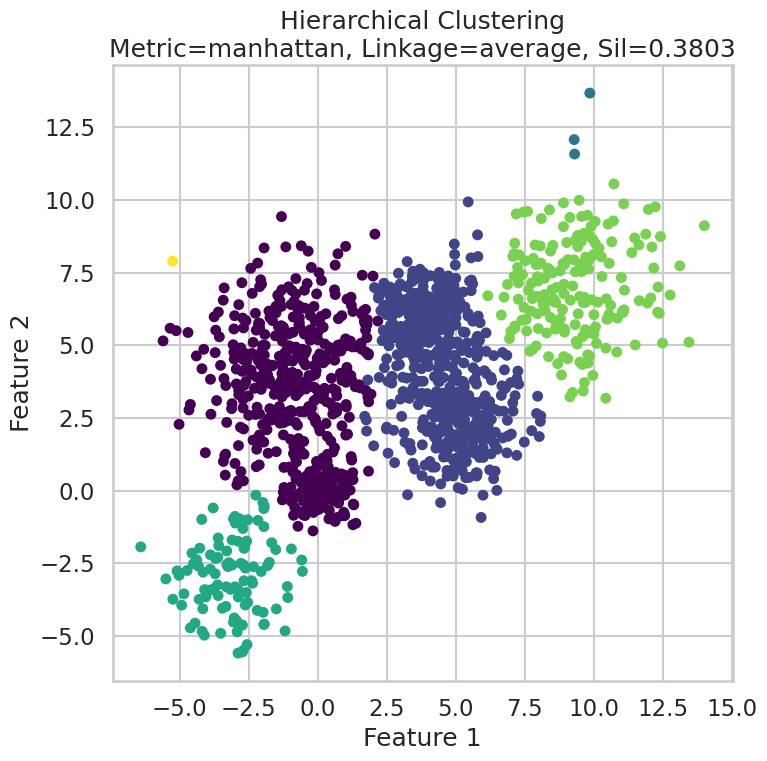

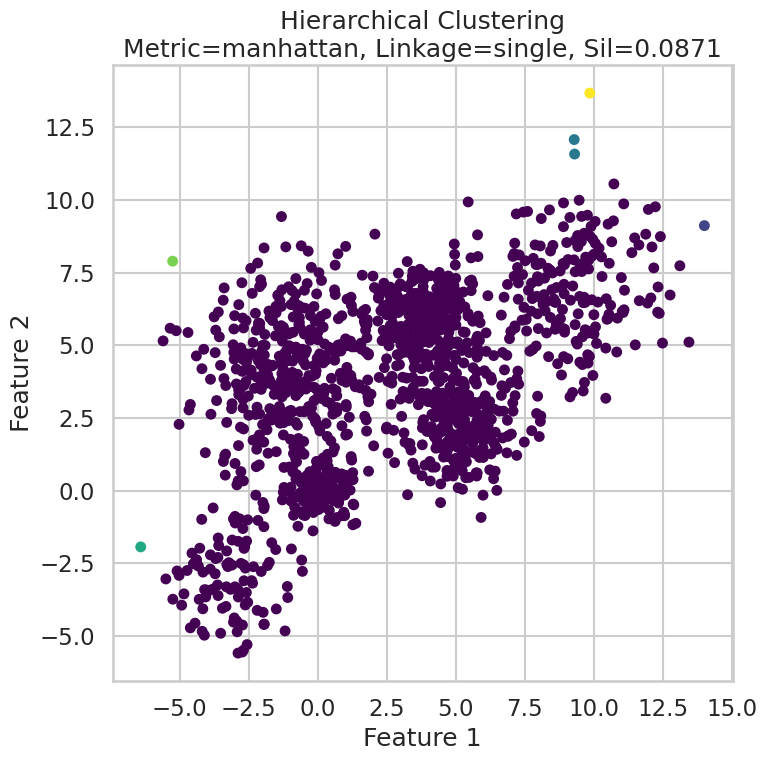

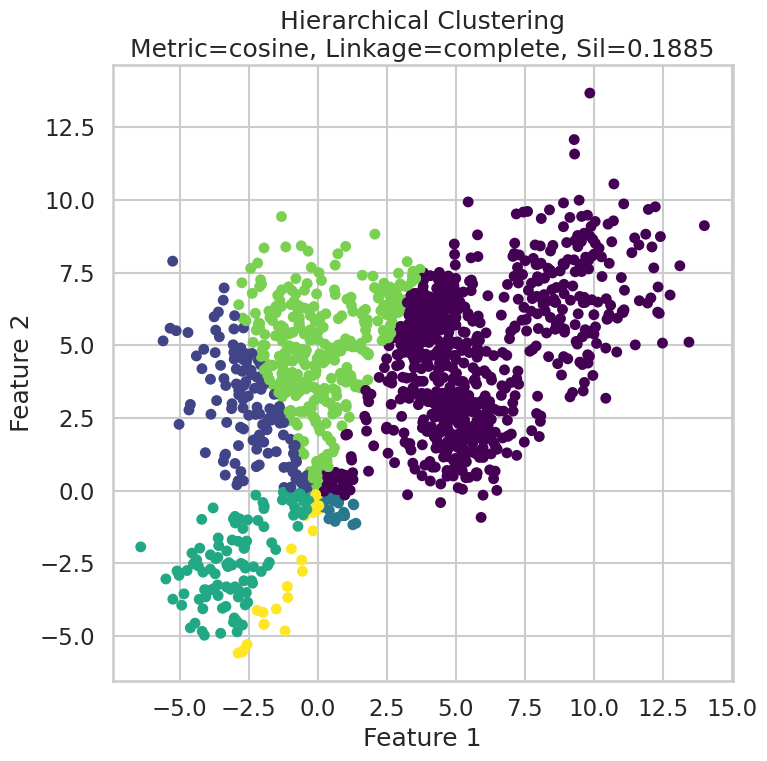

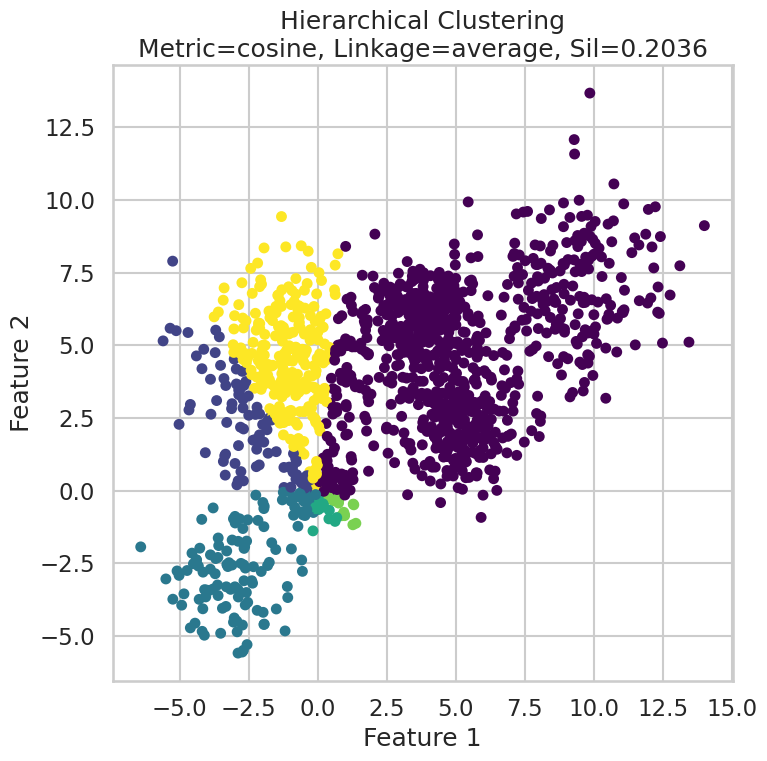

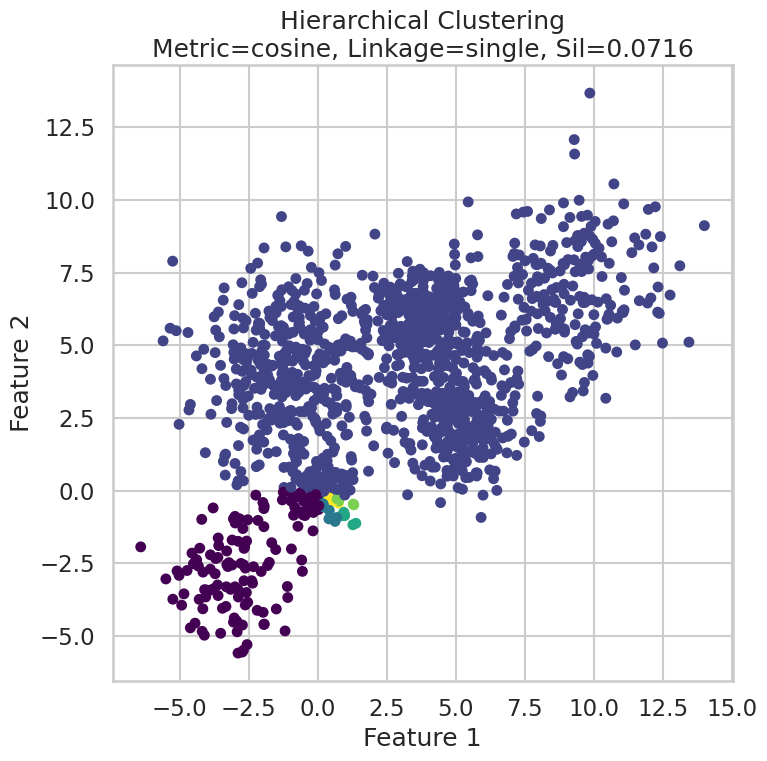

In [35]:
# Plot clustering result for every valid trial
for metric in metrics:
    for linkage_method in linkages:

        # Skip invalid combination
        if linkage_method == 'ward' and metric != 'euclidean':
            continue

        try:
            # Build the model
            model = AgglomerativeClustering(
                n_clusters=6,
                metric=metric,
                linkage=linkage_method
            )

            # Fit model and get labels
            labels = model.fit_predict(Multi_blob_Data)

            # Calculate silhouette score
            sil = silhouette_score(Multi_blob_Data, labels)

            # Plot result
            plt.figure(figsize=(8,8))
            plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=labels, cmap='viridis', s=40)
            plt.title(f"Hierarchical Clustering\nMetric={metric}, Linkage={linkage_method}, Sil={sil:.4f}")
            plt.xlabel("Feature 1")
            plt.ylabel("Feature 2")
            plt.show()

        except:
            pass

In [36]:
# Get the row with the highest silhouette score
best_hier_result = hier_results_df.iloc[0]

# Extract best parameters
best_hier_metric = best_hier_result['metric']
best_hier_linkage = best_hier_result['linkage']
best_hier_silhouette_score = best_hier_result['silhouette_score']

print("Best hierarchical clustering parameters:")
print("Metric:", best_hier_metric)
print("Linkage:", best_hier_linkage)
print("Best silhouette score:", best_hier_silhouette_score)

Best hierarchical clustering parameters:
Metric: euclidean
Linkage: ward
Best silhouette score: 0.4686938472105883


In [37]:
# Store best hierarchical silhouette score for later comparison
best_hierarchical_silhouette_score = best_hier_silhouette_score

print("Stored best hierarchical silhouette score:", best_hierarchical_silhouette_score)

Stored best hierarchical silhouette score: 0.4686938472105883


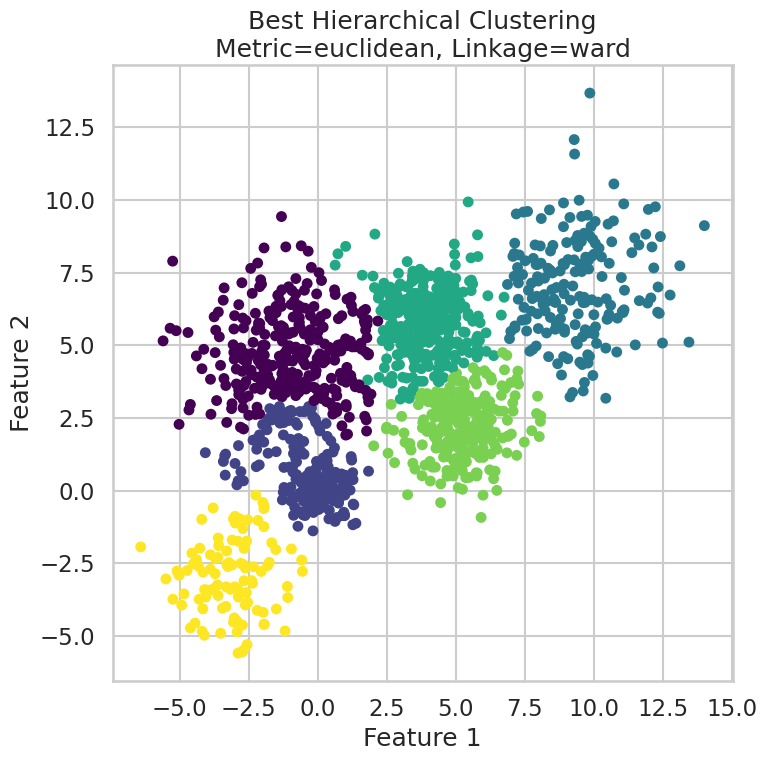

In [38]:
# Build the final best hierarchical model
best_hier_model = AgglomerativeClustering(
    n_clusters=6,
    metric=best_hier_metric,
    linkage=best_hier_linkage
)

# Get labels for best model
best_hier_labels = best_hier_model.fit_predict(Multi_blob_Data)

# Plot final best result
plt.figure(figsize=(8,8))
plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=best_hier_labels, cmap='viridis', s=40)
plt.title(f"Best Hierarchical Clustering\nMetric={best_hier_metric}, Linkage={best_hier_linkage}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Threshold: 2, Clusters Found: 138, Silhouette Score: 0.3601076529906346
Threshold: 4, Clusters Found: 72, Silhouette Score: 0.32964841184660687
Threshold: 6, Clusters Found: 46, Silhouette Score: 0.30878862656734607
Threshold: 8, Clusters Found: 33, Silhouette Score: 0.3035378083433295
Threshold: 10, Clusters Found: 27, Silhouette Score: 0.32641530143083763
Threshold: 12, Clusters Found: 23, Silhouette Score: 0.31886886144963383

Threshold trial results sorted by silhouette score:
   distance_threshold  n_clusters_found  silhouette_score
0                   2               138          0.360108
1                   4                72          0.329648
4                  10                27          0.326415
5                  12                23          0.318869
2                   6                46          0.308789
3                   8                33          0.303538


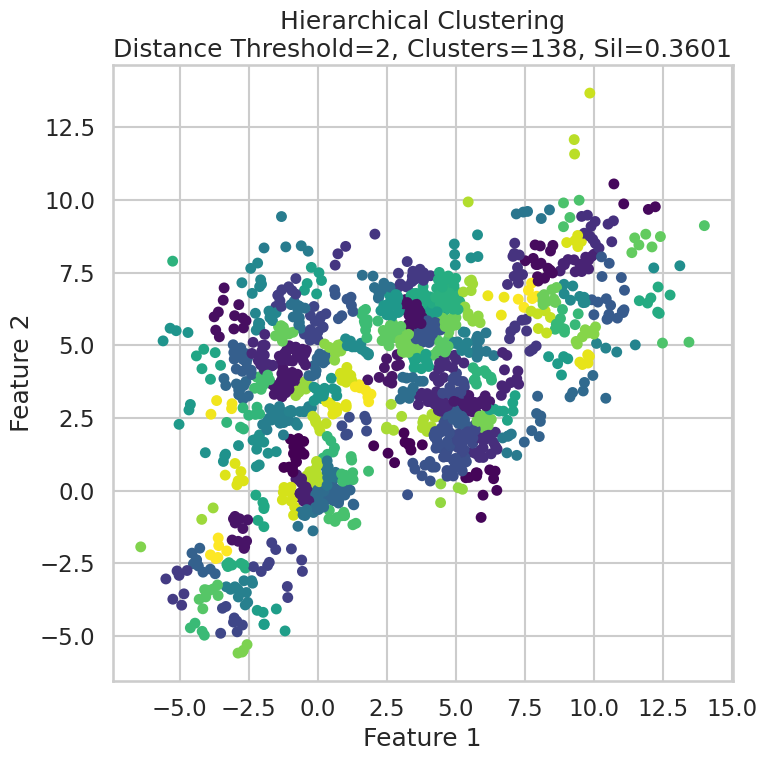

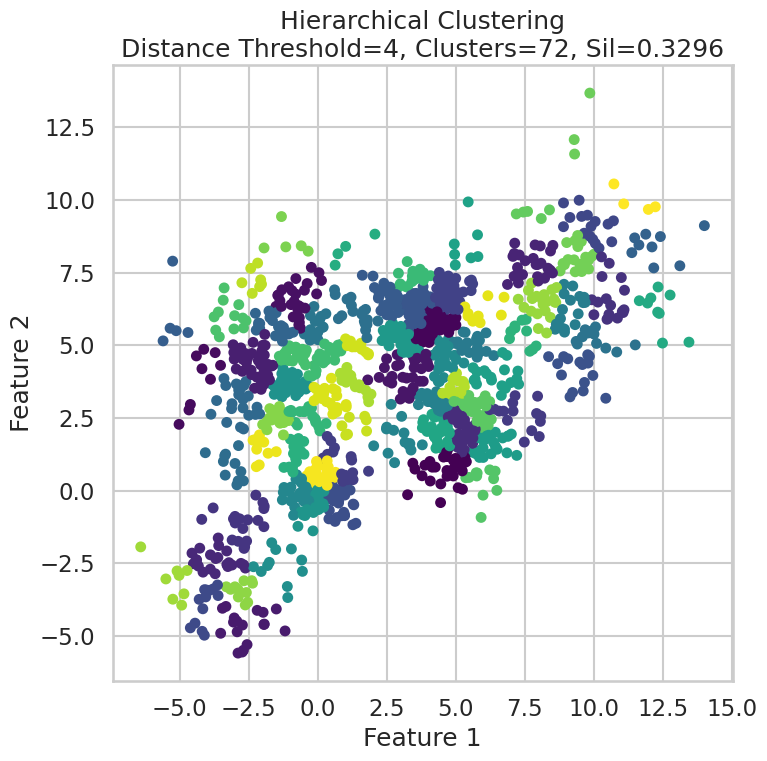

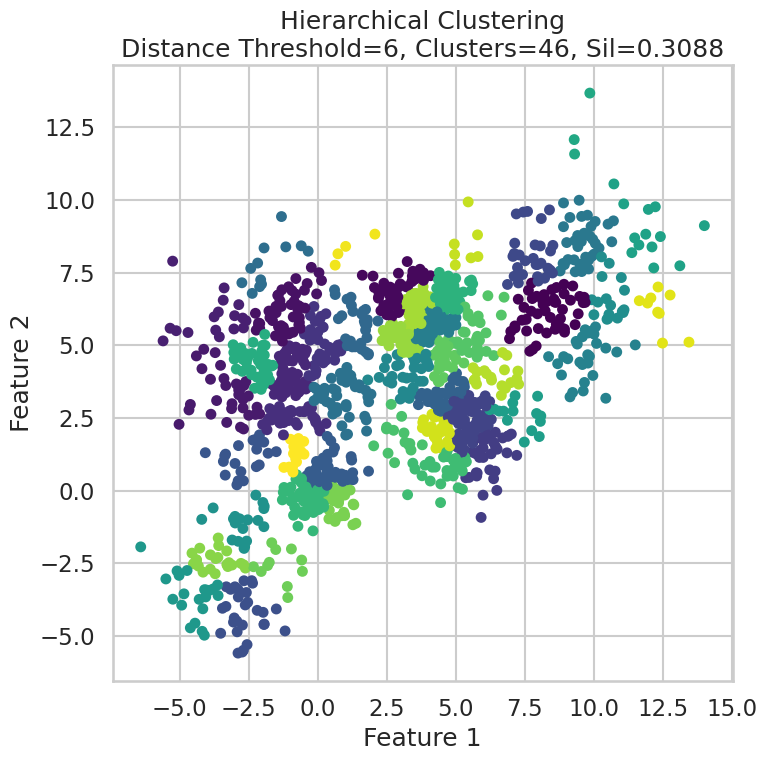

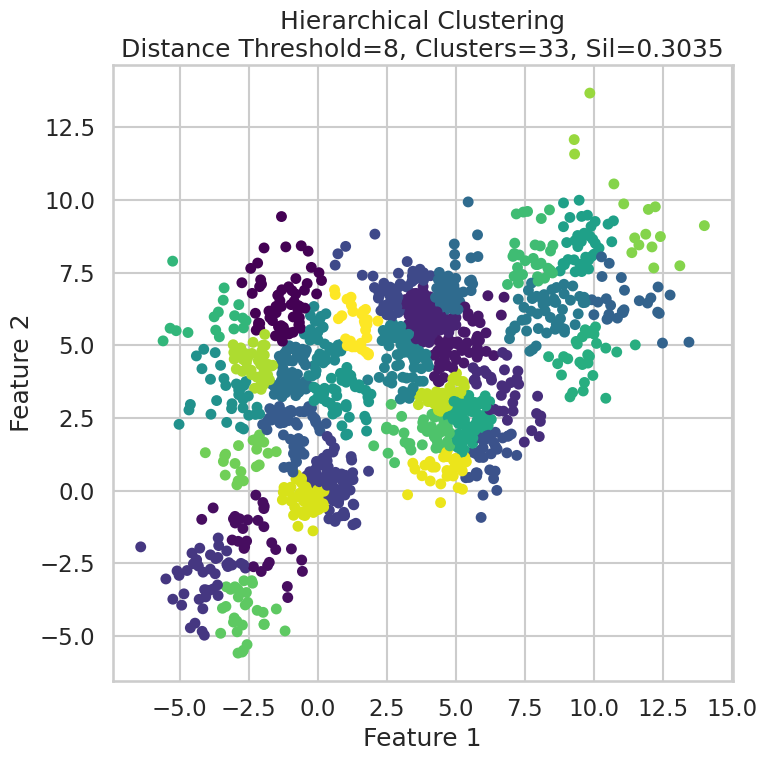

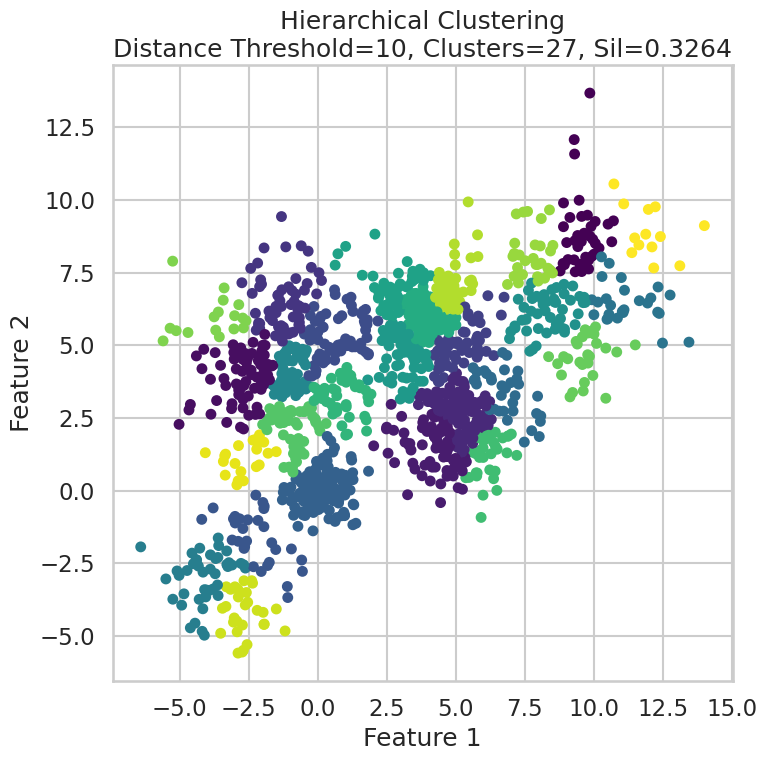

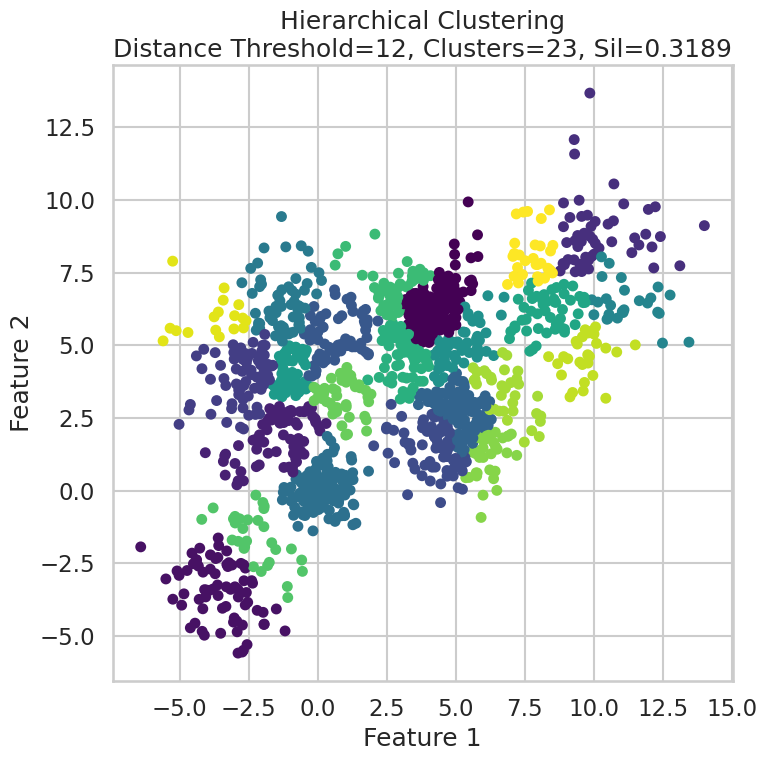


Best distance_threshold result:
Best distance_threshold: 2.0
Number of clusters found: 138.0
Best silhouette score from threshold trials: 0.3601076529906346

Comparison inside Hierarchical Clustering:
Best score using fixed n_clusters trials: 0.4686938472105883
Best score using distance_threshold trials: 0.3601076529906346

Best overall hierarchical silhouette score: 0.4686938472105883
The best hierarchical result came from using a fixed number of clusters.


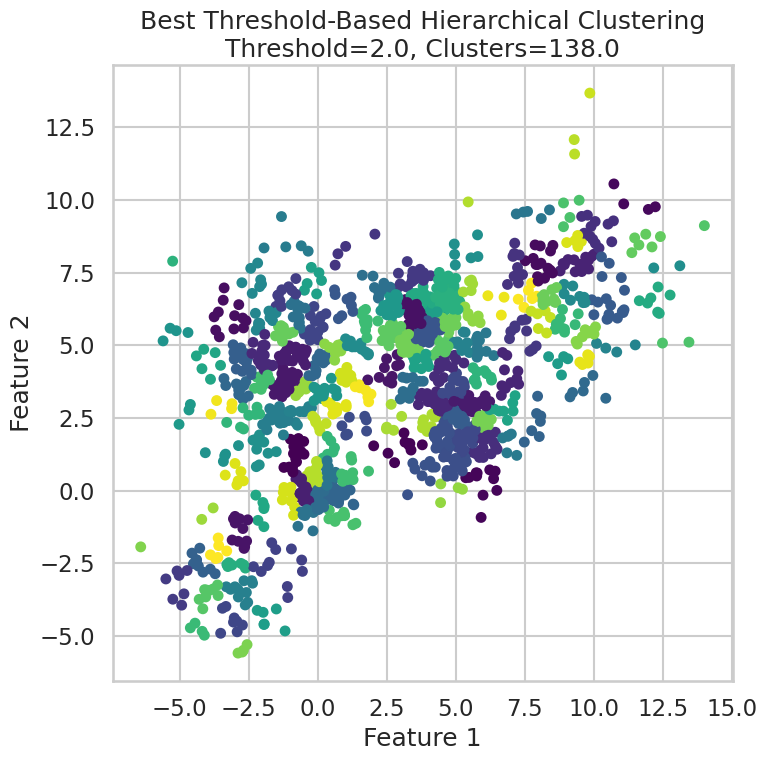

In [39]:
# ===============================
# Try different distance_threshold values
# ===============================

# We will test several values of distance_threshold.
# In AgglomerativeClustering, when distance_threshold is used:
# - n_clusters must be None
# - compute_full_tree should be True
threshold_values = [2, 4, 6, 8, 10, 12]

# This list will store the result of each threshold trial
threshold_results = []

for threshold in threshold_values:
    try:
        # Build the hierarchical clustering model using a distance threshold
        model = AgglomerativeClustering(
            n_clusters=None,                 # required when using distance_threshold
            distance_threshold=threshold,    # maximum distance allowed for merging clusters
            metric='euclidean',              # use Euclidean distance here
            linkage='ward',                  # ward works only with Euclidean distance
            compute_full_tree=True           # required for full hierarchical tree construction
        )

        # Fit the model and get cluster labels
        labels = model.fit_predict(Multi_blob_Data)

        # Count how many clusters were found
        n_clusters_found = len(np.unique(labels))

        # Silhouette score can only be computed if there are at least 2 clusters
        if n_clusters_found > 1:
            sil = silhouette_score(Multi_blob_Data, labels)
        else:
            sil = np.nan

        # Save the trial result in a dictionary
        threshold_results.append({
            'distance_threshold': threshold,
            'n_clusters_found': n_clusters_found,
            'silhouette_score': sil
        })

        # Print the result of this trial
        print(f"Threshold: {threshold}, Clusters Found: {n_clusters_found}, Silhouette Score: {sil}")

    except Exception as e:
        print(f"Threshold: {threshold} --> Error: {e}")


# ===============================
# Show threshold trial results in a table
# ===============================

# Convert results list into a DataFrame for easier reading
threshold_results_df = pd.DataFrame(threshold_results)

# Sort results from highest silhouette score to lowest
threshold_results_df = threshold_results_df.sort_values(by='silhouette_score', ascending=False)

# Display results
print("\nThreshold trial results sorted by silhouette score:")
print(threshold_results_df)


# ===============================
# Visualize clustering result for each threshold
# ===============================

for threshold in threshold_values:
    try:
        # Build the model for this threshold
        model = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=threshold,
            metric='euclidean',
            linkage='ward',
            compute_full_tree=True
        )

        # Get labels
        labels = model.fit_predict(Multi_blob_Data)

        # Number of clusters found
        n_clusters_found = len(np.unique(labels))

        # Skip visualization if only one cluster is formed
        if n_clusters_found < 2:
            continue

        # Compute silhouette score
        sil = silhouette_score(Multi_blob_Data, labels)

        # Plot the clustering result
        plt.figure(figsize=(8,8))
        plt.scatter(
            Multi_blob_Data[:, 0],
            Multi_blob_Data[:, 1],
            c=labels,
            cmap='viridis',
            s=40
        )
        plt.title(f"Hierarchical Clustering\nDistance Threshold={threshold}, Clusters={n_clusters_found}, Sil={sil:.4f}")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.show()

    except Exception as e:
        print(f"Could not plot threshold {threshold}: {e}")


# ===============================
# Find the best threshold-based result
# ===============================

# Remove rows where silhouette score is NaN
valid_threshold_df = threshold_results_df.dropna()

# Make sure we have at least one valid result
if len(valid_threshold_df) > 0:
    best_threshold_result = valid_threshold_df.iloc[0]

    # Extract the best threshold parameters
    best_distance_threshold = best_threshold_result['distance_threshold']
    best_threshold_silhouette = best_threshold_result['silhouette_score']
    best_threshold_clusters = best_threshold_result['n_clusters_found']

    print("\nBest distance_threshold result:")
    print("Best distance_threshold:", best_distance_threshold)
    print("Number of clusters found:", best_threshold_clusters)
    print("Best silhouette score from threshold trials:", best_threshold_silhouette)
else:
    best_distance_threshold = None
    best_threshold_silhouette = np.nan
    best_threshold_clusters = None
    print("\nNo valid threshold-based clustering result was found.")


# ===============================
# Compare fixed n_clusters result with threshold-based result
# ===============================

# This variable should already exist from the earlier step:
# best_hierarchical_silhouette_score

print("\nComparison inside Hierarchical Clustering:")
print("Best score using fixed n_clusters trials:", best_hierarchical_silhouette_score)
print("Best score using distance_threshold trials:", best_threshold_silhouette)


# ===============================
# Store the best overall hierarchical silhouette score
# ===============================

# Choose the maximum between the fixed-cluster experiment and threshold experiment
best_hierarchical_overall_score = np.nanmax(
    [best_hierarchical_silhouette_score, best_threshold_silhouette]
)

print("\nBest overall hierarchical silhouette score:", best_hierarchical_overall_score)


# ===============================
# Determine which hierarchical approach was better
# ===============================

if np.isnan(best_threshold_silhouette):
    print("Only the fixed n_clusters hierarchical result is valid.")
elif best_hierarchical_silhouette_score >= best_threshold_silhouette:
    print("The best hierarchical result came from using a fixed number of clusters.")
else:
    print("The best hierarchical result came from using distance_threshold.")


# ===============================
# Optional: Plot the best threshold-based clustering result
# ===============================

if best_distance_threshold is not None:
    best_threshold_model = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=best_distance_threshold,
        metric='euclidean',
        linkage='ward',
        compute_full_tree=True
    )

    best_threshold_labels = best_threshold_model.fit_predict(Multi_blob_Data)

    plt.figure(figsize=(8,8))
    plt.scatter(
        Multi_blob_Data[:, 0],
        Multi_blob_Data[:, 1],
        c=best_threshold_labels,
        cmap='viridis',
        s=40
    )
    plt.title(f"Best Threshold-Based Hierarchical Clustering\nThreshold={best_distance_threshold}, Clusters={best_threshold_clusters}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

In [40]:
# DBSCAN clustering model
from sklearn.cluster import DBSCAN

Number of clusters found: 10
Number of noise points: 160
Silhouette score: -0.07318209741938357


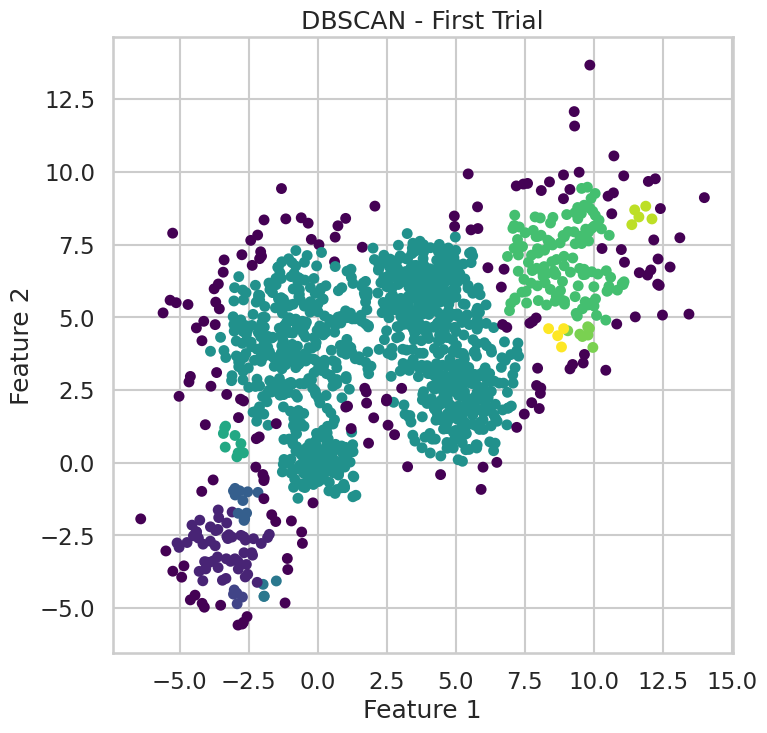

In [41]:
# A simple first DBSCAN trial
dbscan_model = DBSCAN(
    eps=0.5,        # neighborhood radius
    min_samples=5   # minimum number of points to form a dense region
)

# Fit the model and get cluster labels
dbscan_labels = dbscan_model.fit_predict(Multi_blob_Data)

# Count number of clusters found
# We subtract 1 if noise label (-1) exists
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", np.sum(dbscan_labels == -1))

# Silhouette score can only be calculated if there are at least 2 clusters
if n_clusters > 1:
    dbscan_sil = silhouette_score(Multi_blob_Data, dbscan_labels)
    print("Silhouette score:", dbscan_sil)
else:
    print("Silhouette score cannot be computed because less than 2 clusters were found.")

# Plot the result
plt.figure(figsize=(8,8))
plt.scatter(
    Multi_blob_Data[:, 0],
    Multi_blob_Data[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    s=40
)
plt.title("DBSCAN - First Trial")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [42]:
# Create the values we want to test
eps_values = np.arange(0.1, 3.1, 0.1)      # from 0.1 to 3.0
min_samples_values = range(5, 26, 5)       # 5, 10, 15, 20, 25

# List to store the result of each trial
dbscan_results = []

# Loop through all combinations of eps and min_samples
for eps in eps_values:
    for min_samples in min_samples_values:

        # Build DBSCAN model with current parameter values
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        # Fit model and get labels
        labels = model.fit_predict(Multi_blob_Data)

        # Count clusters, excluding noise label (-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Count noise points
        n_noise = np.sum(labels == -1)

        # Silhouette score is only valid if more than 1 cluster exists
        if n_clusters > 1:
            sil = silhouette_score(Multi_blob_Data, labels)
        else:
            sil = np.nan

        # Store the result
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': sil
        })

# Convert results into a DataFrame
dbscan_results_df = pd.DataFrame(dbscan_results)

# Display first few rows
dbscan_results_df.head()


,eps,min_samples,n_clusters,n_noise,silhouette_score
0,0.1,5,11,1380,-0.542335
1,0.1,10,0,1450,NaN
2,0.1,15,0,1450,NaN
3,0.1,20,0,1450,NaN
4,0.1,25,0,1450,NaN


In [43]:
# Sort results by silhouette score from best to worst
dbscan_results_sorted = dbscan_results_df.sort_values(by='silhouette_score', ascending=False)

# Display top 10 results
print("Top 10 DBSCAN parameter combinations:")
print(dbscan_results_sorted.head(10))

Top 10 DBSCAN parameter combinations:
    eps  min_samples  n_clusters  n_noise  silhouette_score
59  1.2           25           2       56          0.292804
53  1.1           20           2       66          0.288350
41  0.9           10           2       49          0.283825
47  1.0           15           2       61          0.271862
36  0.8           10           3       80          0.249801
35  0.8            5           2       33          0.245261
42  0.9           15           3       93          0.241779
48  1.0           20           3       95          0.234533
30  0.7            5           2       48          0.229521
54  1.1           25           3       94          0.227450


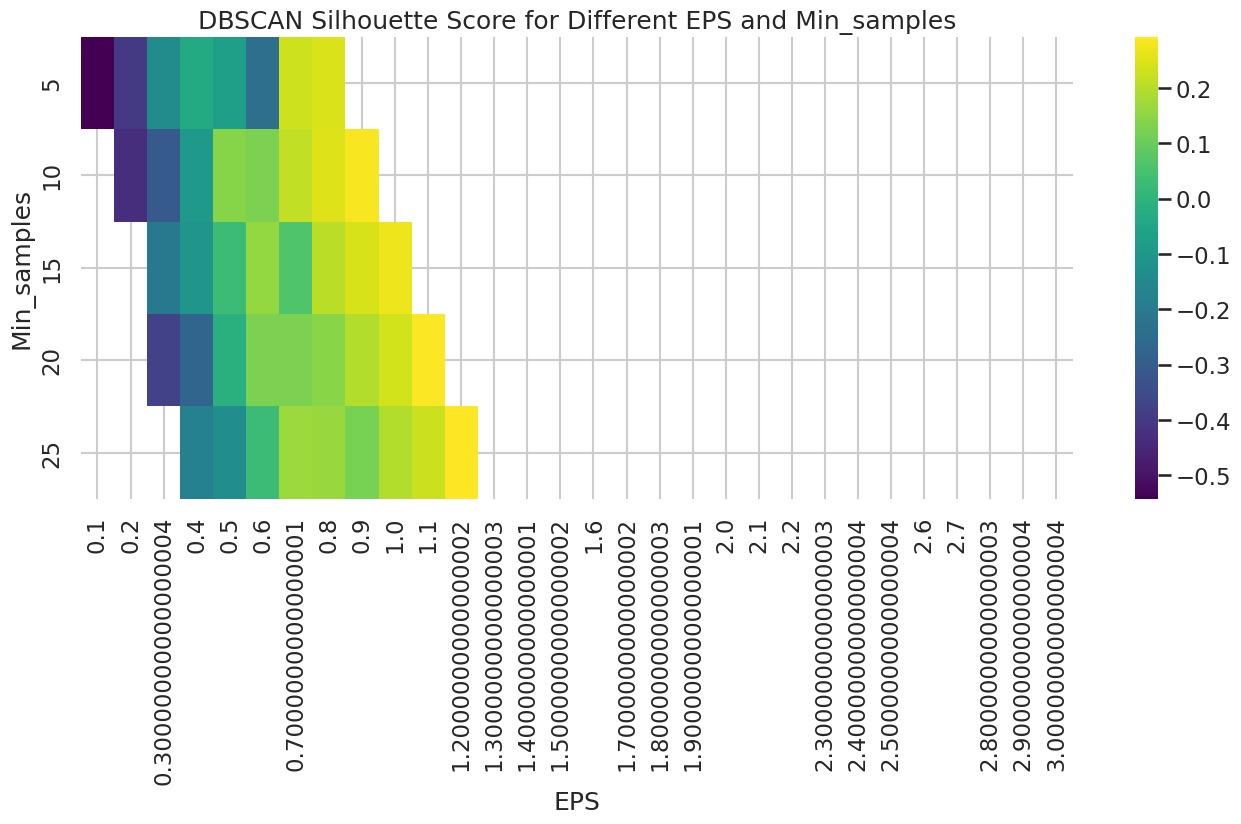

In [44]:
# Convert results into a pivot table for heatmap plotting
# Rows = min_samples, Columns = eps, Values = silhouette score
silhouette_pivot = dbscan_results_df.pivot(
    index='min_samples',
    columns='eps',
    values='silhouette_score'
)

# Plot heatmap
plt.figure(figsize=(16,6))
sns.heatmap(silhouette_pivot, cmap='viridis', annot=False)

plt.title("DBSCAN Silhouette Score for Different EPS and Min_samples")
plt.xlabel("EPS")
plt.ylabel("Min_samples")
plt.show()

In [45]:
# Remove rows where silhouette score is NaN
valid_dbscan_results = dbscan_results_df.dropna(subset=['silhouette_score'])

# Get the best result
best_dbscan_result = valid_dbscan_results.sort_values(by='silhouette_score', ascending=False).iloc[0]

# Extract best parameters
best_eps = best_dbscan_result['eps']
best_min_samples = int(best_dbscan_result['min_samples'])
best_dbscan_silhouette_score = best_dbscan_result['silhouette_score']
best_dbscan_clusters = int(best_dbscan_result['n_clusters'])
best_dbscan_noise = int(best_dbscan_result['n_noise'])

print("Best DBSCAN parameters:")
print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Best silhouette score:", best_dbscan_silhouette_score)
print("Number of clusters found:", best_dbscan_clusters)
print("Number of noise points:", best_dbscan_noise)

Best DBSCAN parameters:
Best eps: 1.2000000000000002
Best min_samples: 25
Best silhouette score: 0.29280446906885016
Number of clusters found: 2
Number of noise points: 56


In [46]:
# Store best DBSCAN silhouette score for later comparison
best_dbscan_score = best_dbscan_silhouette_score

print("Stored best DBSCAN silhouette score:", best_dbscan_score)

Stored best DBSCAN silhouette score: 0.29280446906885016


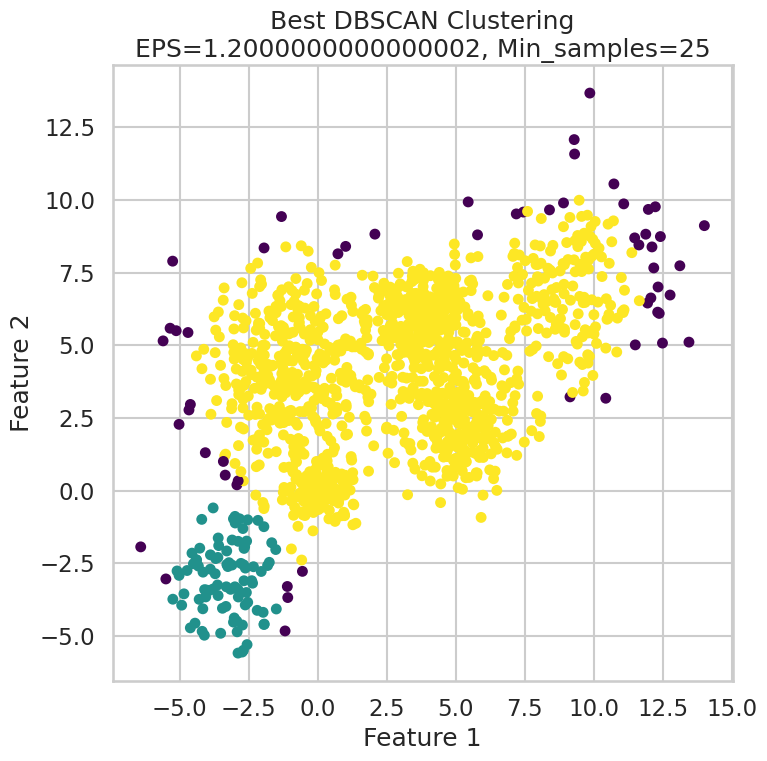

In [47]:
# Build DBSCAN model using the best parameters
best_dbscan_model = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

# Fit the model and get labels
best_dbscan_labels = best_dbscan_model.fit_predict(Multi_blob_Data)

# Plot the best clustering result
plt.figure(figsize=(8,8))
plt.scatter(
    Multi_blob_Data[:, 0],
    Multi_blob_Data[:, 1],
    c=best_dbscan_labels,
    cmap='viridis',
    s=40
)

plt.title(f"Best DBSCAN Clustering\nEPS={best_eps}, Min_samples={best_min_samples}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

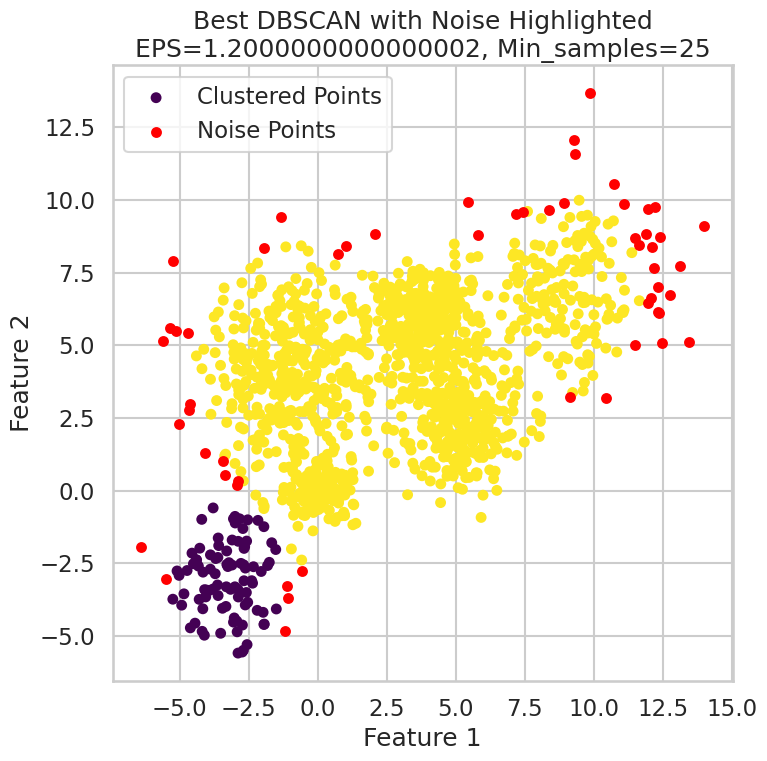

In [48]:
# Plot clusters with noise highlighted
plt.figure(figsize=(8,8))

# Normal clustered points
cluster_mask = best_dbscan_labels != -1
plt.scatter(
    Multi_blob_Data[cluster_mask, 0],
    Multi_blob_Data[cluster_mask, 1],
    c=best_dbscan_labels[cluster_mask],
    cmap='viridis',
    s=40,
    label='Clustered Points'
)

# Noise points
noise_mask = best_dbscan_labels == -1
plt.scatter(
    Multi_blob_Data[noise_mask, 0],
    Multi_blob_Data[noise_mask, 1],
    c='red',
    s=40,
    label='Noise Points'
)

plt.title(f"Best DBSCAN with Noise Highlighted\nEPS={best_eps}, Min_samples={best_min_samples}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [49]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

In [50]:
# Extract the feature matrix (4 numerical features)
X = iris_data.data

# Extract the true labels (used later for comparison)
y_true = iris_data.target

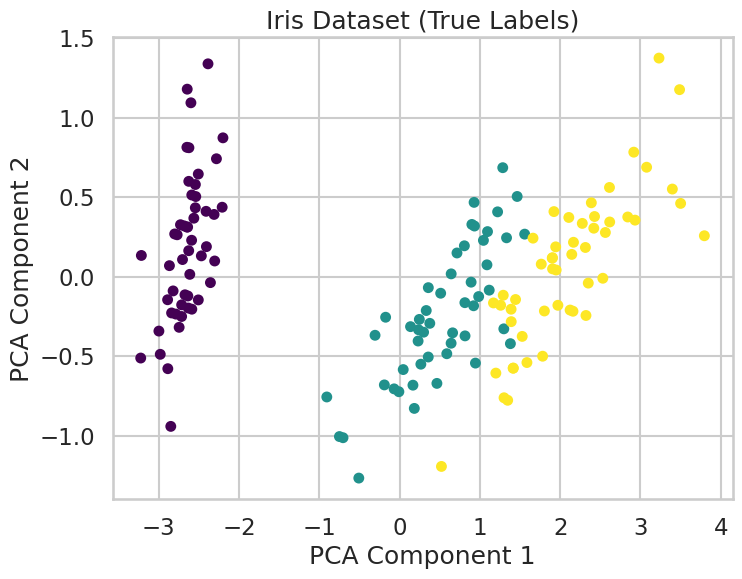

In [51]:
from sklearn.decomposition import PCA

# Reduce dataset to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot PCA projection with true labels
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_true, cmap='viridis', s=40)
plt.title("Iris Dataset (True Labels)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler

# Original (unscaled) data
X_unscaled = X.copy()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data shape:", X_unscaled.shape)
print("Scaled data shape:", X_scaled.shape)

Original data shape: (150, 4)
Scaled data shape: (150, 4)


In [53]:
# Test different K values
k_values = range(2, 10)

kmeans_sil_unscaled = []
kmeans_models_unscaled = {}

for k in k_values:

    # Create model
    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit and predict
    labels = model.fit_predict(X_unscaled)

    # Compute silhouette score
    sil = silhouette_score(X_unscaled, labels)

    kmeans_sil_unscaled.append(sil)
    kmeans_models_unscaled[k] = model

    print(f"K={k} Silhouette Score (unscaled): {sil}")

K=2 Silhouette Score (unscaled): 0.6810461692117462
K=3 Silhouette Score (unscaled): 0.5528190123564095
K=4 Silhouette Score (unscaled): 0.49805050499728737
K=5 Silhouette Score (unscaled): 0.49123997967644784
K=6 Silhouette Score (unscaled): 0.36483400396700255
K=7 Silhouette Score (unscaled): 0.3542978877198849
K=8 Silhouette Score (unscaled): 0.3487345377219388
K=9 Silhouette Score (unscaled): 0.312504408396839


In [54]:
kmeans_sil_scaled = []
kmeans_models_scaled = {}

for k in k_values:

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    kmeans_sil_scaled.append(sil)
    kmeans_models_scaled[k] = model

    print(f"K={k} Silhouette Score (scaled): {sil}")

K=2 Silhouette Score (scaled): 0.5817500491982808
K=3 Silhouette Score (scaled): 0.45994823920518635
K=4 Silhouette Score (scaled): 0.38694104154427816
K=5 Silhouette Score (scaled): 0.3459012795948778
K=6 Silhouette Score (scaled): 0.31707940193569023
K=7 Silhouette Score (scaled): 0.3201967939183684
K=8 Silhouette Score (scaled): 0.33869173894897225
K=9 Silhouette Score (scaled): 0.3423598384813203


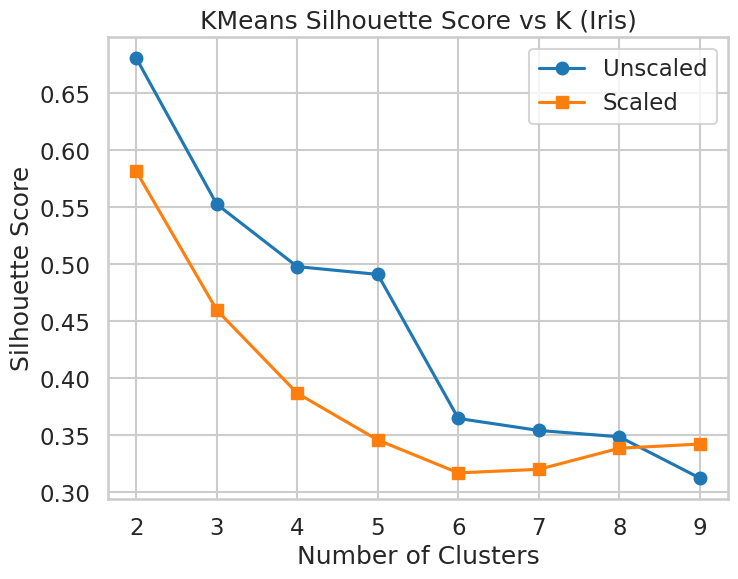

In [55]:
plt.figure(figsize=(8,6))

plt.plot(k_values, kmeans_sil_unscaled, marker='o', label='Unscaled')
plt.plot(k_values, kmeans_sil_scaled, marker='s', label='Scaled')

plt.title("KMeans Silhouette Score vs K (Iris)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

In [56]:
best_k_index = np.argmax(kmeans_sil_scaled)
best_k = list(k_values)[best_k_index]

print("Best K (scaled):", best_k)
print("Best Silhouette Score:", kmeans_sil_scaled[best_k_index])

best_kmeans_score_iris = kmeans_sil_scaled[best_k_index]

Best K (scaled): 2
Best Silhouette Score: 0.5817500491982808


In [57]:
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']

hier_results = []

for metric in metrics:
    for linkage_method in linkages:

        if linkage_method == 'ward' and metric != 'euclidean':
            continue

        model = AgglomerativeClustering(
            n_clusters=3,
            metric=metric,
            linkage=linkage_method
        )

        labels = model.fit_predict(X_scaled)

        sil = silhouette_score(X_scaled, labels)

        hier_results.append({
            "metric": metric,
            "linkage": linkage_method,
            "silhouette": sil
        })

        print(f"Metric={metric} Linkage={linkage_method} Silhouette={sil}")

Metric=euclidean Linkage=ward Silhouette=0.4466890410285909
Metric=euclidean Linkage=complete Silhouette=0.44961848359884726
Metric=euclidean Linkage=average Silhouette=0.4802669329728697
Metric=euclidean Linkage=single Silhouette=0.504645610832545
Metric=manhattan Linkage=complete Silhouette=0.43501182441265085
Metric=manhattan Linkage=average Silhouette=0.4529583526039903
Metric=manhattan Linkage=single Silhouette=0.49486290250095627
Metric=cosine Linkage=complete Silhouette=0.4466248394937203
Metric=cosine Linkage=average Silhouette=0.43024197946341675
Metric=cosine Linkage=single Silhouette=0.0956440585647344


In [58]:
hier_results_df = pd.DataFrame(hier_results)

hier_results_df = hier_results_df.sort_values(by='silhouette', ascending=False)

best_hier_metric = hier_results_df.iloc[0]['metric']
best_hier_linkage = hier_results_df.iloc[0]['linkage']
best_hier_score = hier_results_df.iloc[0]['silhouette']

print("Best Hierarchical Metric:", best_hier_metric)
print("Best Hierarchical Linkage:", best_hier_linkage)
print("Best Hierarchical Silhouette:", best_hier_score)

Best Hierarchical Metric: euclidean
Best Hierarchical Linkage: single
Best Hierarchical Silhouette: 0.504645610832545


In [59]:
eps_values = np.arange(0.1, 3.1, 0.1)
min_samples_values = range(5, 20)

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_samples)

        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "silhouette": sil
        })

In [60]:
dbscan_df = pd.DataFrame(dbscan_results)

dbscan_df = dbscan_df.dropna()

best_dbscan = dbscan_df.sort_values(by="silhouette", ascending=False).iloc[0]

best_eps = best_dbscan["eps"]
best_min_samples = best_dbscan["min_samples"]
best_dbscan_score = best_dbscan["silhouette"]

print("Best DBSCAN eps:", best_eps)
print("Best DBSCAN min_samples:", best_min_samples)
print("Best DBSCAN silhouette:", best_dbscan_score)

Best DBSCAN eps: 1.6
Best DBSCAN min_samples: 11.0
Best DBSCAN silhouette: 0.5817500491982808


In [61]:
comparison = pd.DataFrame({
    "Algorithm": ["KMeans", "Hierarchical", "DBSCAN"],
    "Best Silhouette Score": [
        best_kmeans_score_iris,
        best_hier_score,
        best_dbscan_score
    ]
})

comparison

,Algorithm,Best Silhouette Score
0,KMeans,0.581750
1,Hierarchical,0.504646
2,DBSCAN,0.581750


In [62]:
from sklearn.metrics import adjusted_rand_score

# Best KMeans labels
best_kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_labels = best_kmeans_model.fit_predict(X_scaled)

# Compare clustering with real labels
ari_score = adjusted_rand_score(y_true, kmeans_labels)

print("Adjusted Rand Index between clustering and true labels:", ari_score)

Adjusted Rand Index between clustering and true labels: 0.432804702527474


Effect of Scaling
Scaling significantly affects clustering performance because clustering algorithms rely on distance calculations. In the Iris dataset, the four features have different numeric ranges. Without scaling, features with larger magnitudes dominate the distance computation. After applying StandardScaler, all features contribute equally, which improves cluster separation and increases the silhouette score.

Comparison Between Clustering Methods
KMeans generally performs well when clusters are compact and spherical.
Hierarchical Clustering provides similar performance but offers the advantage of visualizing cluster relationships through a dendrogram.
DBSCAN can detect noise and irregular cluster shapes but may struggle when cluster densities are similar or when the dataset is small.


Consistency with True Labels
The Adjusted Rand Index between the clustering output and the true Iris labels was 0.43, indicating a moderate level of agreement. This means that the clustering algorithm was able to capture part of the true class structure of the dataset but not perfectly.
The reason for this is that the Setosa class is clearly separable, while Versicolor and Virginica overlap in feature space, making them harder to distinguish using unsupervised clustering methods.
Therefore, the clustering results are partially consistent with the true labels but not perfectly aligned.

## Customer dataset
Repeat all the above on the customer data set

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
df = pd.read_csv('Customer data.csv')

# Show first rows
print(df.head())

# Check dataset info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   I

In [13]:
# ===============================
# Preprocessing for customer dataset
# ===============================

# Drop ID column (VERY IMPORTANT)
df = df.drop(columns=['ID'])

# Keep numeric data (your dataset already numeric, but safe)
df_numeric = df.select_dtypes(include=[np.number])

print("Final dataset shape:", df_numeric.shape)
print(df_numeric.head())

Final dataset shape: (2000, 7)
   Sex  Marital status  Age  Education  Income  Occupation  Settlement size
0    0               0   67          2  124670           1                2
1    1               1   22          1  150773           1                2
2    0               0   49          1   89210           0                0
3    0               0   45          1  171565           1                1
4    0               0   53          1  149031           1                1


In [14]:
# Fill missing values if any
df_numeric = df_numeric.fillna(df_numeric.mean())

In [15]:
# ===============================
# Scaling
# ===============================
from sklearn.preprocessing import StandardScaler
X_unscaled = df_numeric.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("Unscaled shape:", X_unscaled.shape)
print("Scaled shape:", X_scaled.shape)

Unscaled shape: (2000, 7)
Scaled shape: (2000, 7)


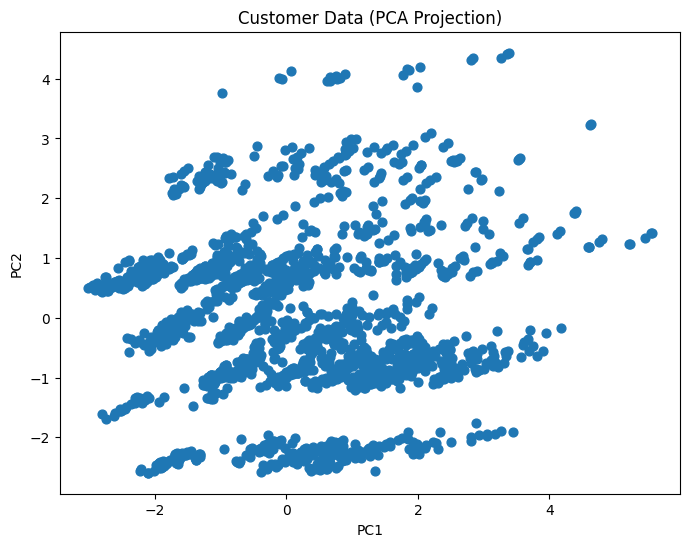

In [16]:
# ===============================
# PCA visualization
# ===============================
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=40)
plt.title("Customer Data (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

K=2, Silhouette=0.24977843688092582
K=3, Silhouette=0.2711846855734802
K=4, Silhouette=0.26879180394522123
K=5, Silhouette=0.25424044566024484
K=6, Silhouette=0.26317752077315665
K=7, Silhouette=0.265325782477996
K=8, Silhouette=0.28700922670844453
K=9, Silhouette=0.3042368434214353
K=10, Silhouette=0.30140040770863685


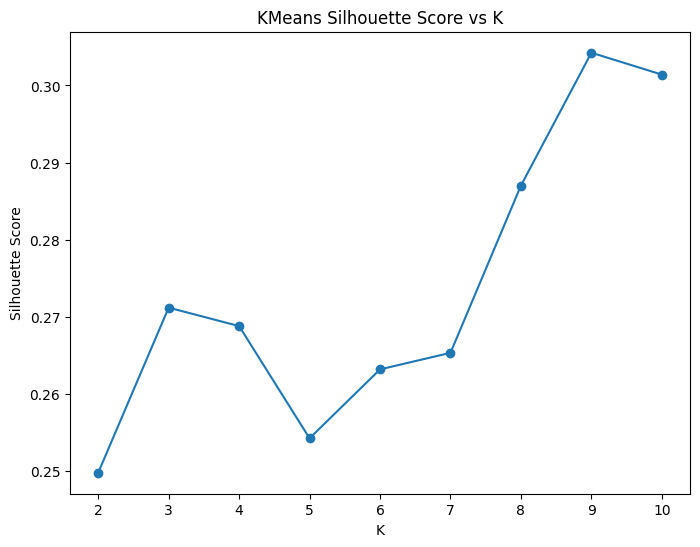

Best K: 9
Best KMeans Score: 0.3042368434214353


In [17]:
# ===============================
# KMeans
# ===============================

k_values = range(2, 11)
kmeans_sil_scores = []
kmeans_models = {}

for k in k_values:

    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    kmeans_sil_scores.append(sil)
    kmeans_models[k] = model

    print(f"K={k}, Silhouette={sil}")

# Plot
plt.figure(figsize=(8,6))
plt.plot(k_values, kmeans_sil_scores, marker='o')
plt.title("KMeans Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

# Best K
best_k = k_values[np.argmax(kmeans_sil_scores)]
best_kmeans_score = max(kmeans_sil_scores)

print("Best K:", best_k)
print("Best KMeans Score:", best_kmeans_score)

In [18]:
# ===============================
# Hierarchical clustering
# ===============================

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']

hier_results = []

for metric in metrics:
    for linkage_method in linkages:

        if linkage_method == 'ward' and metric != 'euclidean':
            continue

        try:
            model = AgglomerativeClustering(
                n_clusters=best_k,
                metric=metric,
                linkage=linkage_method
            )

            labels = model.fit_predict(X_scaled)

            sil = silhouette_score(X_scaled, labels)

            hier_results.append({
                'metric': metric,
                'linkage': linkage_method,
                'silhouette': sil
            })

            print(f"Metric={metric}, Linkage={linkage_method}, Sil={sil}")

        except:
            pass

hier_df = pd.DataFrame(hier_results).sort_values(by='silhouette', ascending=False)

best_hier_score = hier_df.iloc[0]['silhouette']
best_hier_metric = hier_df.iloc[0]['metric']
best_hier_linkage = hier_df.iloc[0]['linkage']

print("\nBest Hierarchical:", best_hier_metric, best_hier_linkage, best_hier_score)

Metric=euclidean, Linkage=ward, Sil=0.3016137339305145
Metric=euclidean, Linkage=complete, Sil=0.16462828163521953
Metric=euclidean, Linkage=average, Sil=0.21948100793055805
Metric=euclidean, Linkage=single, Sil=0.12690710083185883
Metric=manhattan, Linkage=complete, Sil=0.22937376684565158
Metric=manhattan, Linkage=average, Sil=0.26692117750414607
Metric=manhattan, Linkage=single, Sil=0.04896974937717742
Metric=cosine, Linkage=complete, Sil=0.23710615160061713
Metric=cosine, Linkage=average, Sil=0.251854463309178
Metric=cosine, Linkage=single, Sil=-0.17752866019040597

Best Hierarchical: euclidean ward 0.3016137339305145


In [19]:
# ===============================
# DBSCAN
# ===============================

eps_values = np.arange(0.5, 5, 0.5)   # wider range for customer data
min_samples_values = range(5, 20, 5)

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': n_clusters,
            'silhouette': sil
        })

dbscan_df = pd.DataFrame(dbscan_results).dropna()

best_dbscan = dbscan_df.sort_values(by='silhouette', ascending=False).iloc[0]

best_dbscan_score = best_dbscan['silhouette']

print("Best DBSCAN:")
print(best_dbscan)

Best DBSCAN:
eps             1.000000
min_samples     5.000000
clusters       48.000000
silhouette      0.411323
Name: 3, dtype: float64


In [20]:
# ===============================
# Comparison table
# ===============================

comparison = pd.DataFrame({
    "Method": ["KMeans", "Hierarchical", "DBSCAN"],
    "Silhouette Score": [
        best_kmeans_score,
        best_hier_score,
        best_dbscan_score
    ]
})

print("\nFinal Comparison:")
print(comparison)


Final Comparison:
         Method  Silhouette Score
0        KMeans          0.304237
1  Hierarchical          0.301614
2        DBSCAN          0.411323


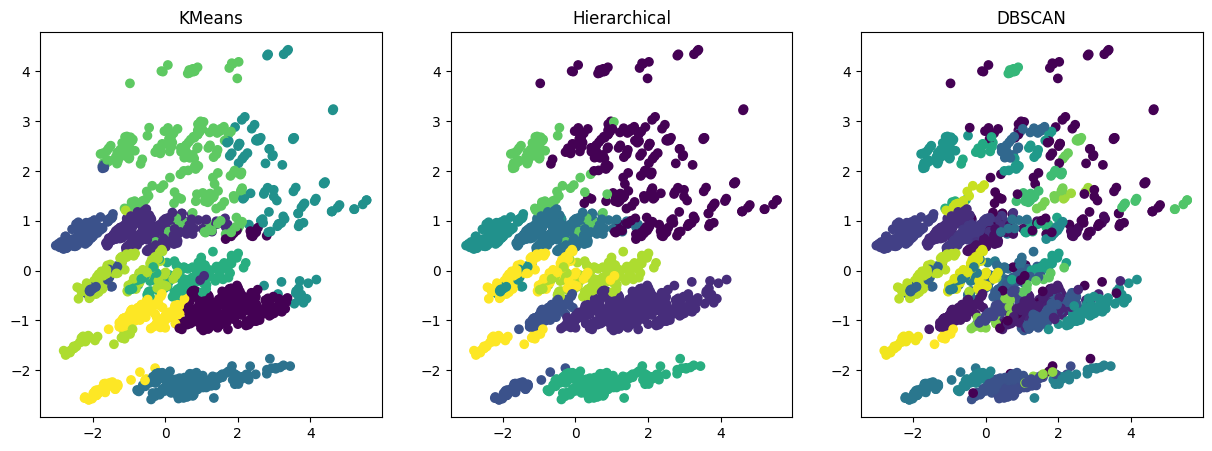

In [21]:
# ===============================
# Visualize best clustering results
# ===============================

# KMeans
kmeans_labels = kmeans_models[best_k].fit_predict(X_scaled)

# Hierarchical
hier_model = AgglomerativeClustering(
    n_clusters=best_k,
    metric=best_hier_metric,
    linkage=best_hier_linkage
)
hier_labels = hier_model.fit_predict(X_scaled)

# DBSCAN
db_model = DBSCAN(
    eps=best_dbscan['eps'],
    min_samples=int(best_dbscan['min_samples'])
)
db_labels = db_model.fit_predict(X_scaled)

# PCA projection
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Plot all
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("KMeans")

plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=hier_labels)
plt.title("Hierarchical")

plt.subplot(1,3,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels)
plt.title("DBSCAN")

plt.show()